In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from collections import Counter
from wordcloud import WordCloud
import re
import warnings
warnings.filterwarnings("ignore")

#Style 
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.15)
PALETTE   = ["#4C72B0","#DD8452","#55A868","#C44E52","#8172B2",
             "#937860","#DA8BC3","#8C8C8C","#CCB974","#64B5CD","#4CAF50","#E91E63"]
PLT_SIZE  = (14, 5)
plt.rcParams.update({"figure.dpi": 120, "figure.facecolor": "white"})

PLATFORMS = [
    "Alibaba","Aliexpress","Amazon shopping","Daraz Online Shopping App",
    "eBay online shopping & selling","Flipkart","Lazada","Meesho",
    "Myntra","Shein","Snapdeal","Walmart"
]
print(" Imports done")

 Imports done


# 2.Data Load

In [2]:
DATA_PATH ='/kaggle/input/notebooks/bennjimatakwa/datamerge-01/data/processed/merged_reviews.csv'
df = pd.read_csv(DATA_PATH)

# Parse timestamps (milliseconds → datetime)
df["datetime"]  = pd.to_datetime(df["at"], unit="ms", errors="coerce")
df["year"]      = df["datetime"].dt.year
df["month"]     = df["datetime"].dt.month
df["month_name"]= df["datetime"].dt.strftime("%b")
df["dow"]       = df["datetime"].dt.day_name()
df["hour"]      = df["datetime"].dt.hour

# Derived text features
df["review_length"] = df["content"].astype(str).str.len()
df["word_count"]    = df["content"].astype(str).str.split().str.len()
df["has_reply"]     = df["replyContent"].notna().astype(int)

# Sentiment label (for plots)
df["sentiment"] = df["score"].map({1:"Negative",2:"Negative",3:"Neutral",4:"Positive",5:"Positive"})

print(f" Loaded {len(df):,} rows × {df.shape[1]} columns")
print(f"   Date range : {df['datetime'].min().date()} → {df['datetime'].max().date()}")

 Loaded 630,000 rows × 18 columns
   Date range : 2018-09-12 → 2024-08-17


# lets view our folders 


In [3]:
import os

def explore(path, indent=0):
    try:
        for item in os.listdir(path):
            full = os.path.join(path, item)
            if os.path.isdir(full):
                print('  ' * indent + f'  {item}/')
                explore(full, indent + 1)
            else:
                mb = os.path.getsize(full) / 1e6
                print('  ' * indent + f'└── {item}  ({mb:.1f} MB)')
    except:
        pass

explore('/kaggle/input')

  code/
    deleted/
      116755925/
  notebooks/
    bennjimatakwa/
      datamerge-01/
      └── __results__.html  (0.3 MB)
      └── __notebook__.ipynb  (0.0 MB)
      └── __output__.json  (0.0 MB)
        data/
          processed/
          └── merged_reviews.csv  (184.2 MB)
      └── custom.css  (0.0 MB)


# Shape of our data 

In [4]:
print(f"  Shape        : {df.shape[0]:,} rows  ×  {df.shape[1]} columns")
print(f"  Platforms    : {df['appName'].nunique()}")
print(f"  Date range   : {df['datetime'].min().date()} → {df['datetime'].max().date()}")
print(f"  Unique reviews: {df['reviewId'].nunique():,}")
df.dtypes.to_frame("dtype").assign(non_null=df.notna().sum(), null=df.isna().sum())

  Shape        : 630,000 rows  ×  18 columns
  Platforms    : 11
  Date range   : 2018-09-12 → 2024-08-17
  Unique reviews: 630,000


,dtype,non_null,null
reviewId,object,630000,0
content,object,629999,1
score,int64,630000,0
thumbsUpCount,int64,630000,0
at,int64,630000,0
replyContent,object,166488,463512
repliedAt,float64,166488,463512
appName,object,630000,0
datetime,datetime64[ns],630000,0
year,int32,630000,0


In [5]:
# Sample rows
df[["appName","score","content","thumbsUpCount","datetime","has_reply"]].sample(5, random_state=1)


,appName,score,content,thumbsUpCount,datetime,has_reply
213536,Aliexpress,5,A nice app to get quality products,0,2019-11-07 19:44:45,0
329335,Lazada,1,Horrible customer service Lazada cancelled my ...,0,2023-04-02 02:58:40,1
540535,Daraz Online Shopping App,1,This app is very slow in function its waste al...,4,2023-12-31 14:16:25,1
72563,Alibaba,5,THIS IS BEST APP👍🏻,0,2021-07-04 20:35:48,1
448377,Amazon shopping,3,they don't apply for the price match,0,2021-08-27 23:05:10,0


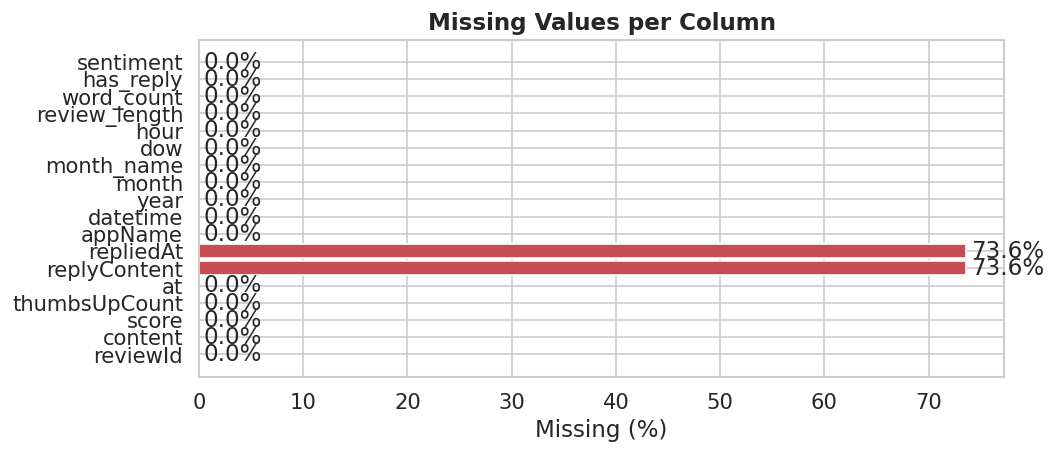

       Column  Missing     %
     reviewId        0  0.00
      content        1  0.00
        score        0  0.00
thumbsUpCount        0  0.00
           at        0  0.00
 replyContent   463512 73.57
    repliedAt   463512 73.57
      appName        0  0.00
     datetime        0  0.00
         year        0  0.00
        month        0  0.00
   month_name        0  0.00
          dow        0  0.00
         hour        0  0.00
review_length        0  0.00
   word_count        0  0.00
    has_reply        0  0.00
    sentiment        0  0.00


In [6]:
missing = df.isnull().sum().reset_index()
missing.columns = ["Column", "Missing"]
missing["%"] = (missing["Missing"] / len(df) * 100).round(2)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(missing["Column"], missing["%"], color=["#C44E52" if x > 0 else "#55A868" for x in missing["%"]])
ax.bar_label(bars, fmt="%.1f%%", padding=3)
ax.set_xlabel("Missing (%)")
ax.set_title("Missing Values per Column", fontweight="bold")
plt.tight_layout()
plt.show()
print(missing.to_string(index=False))

# 2.2 Descreptive Statistics 

In [7]:
df[["score","thumbsUpCount","review_length","word_count"]].describe().round(2)

,score,thumbsUpCount,review_length,word_count
count,630000.00,630000.00,630000.00,630000.00
mean,3.21,12.25,163.73,30.08
std,1.79,216.86,137.65,25.43
min,1.00,0.00,3.00,1.00
25%,1.00,0.00,53.00,10.00
50%,4.00,0.00,120.00,22.00
75%,5.00,1.00,238.00,44.00
max,5.00,34774.00,2174.00,390.00


# 3 Platform Analysis


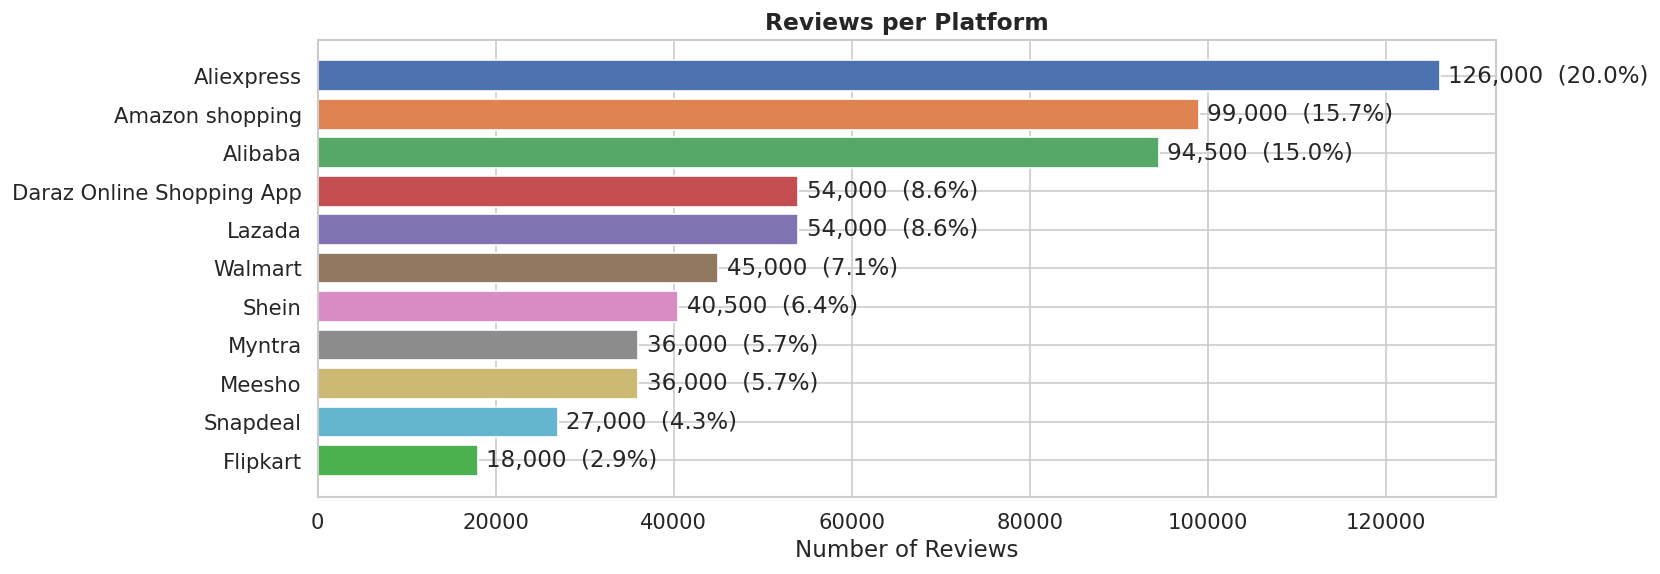

In [8]:
counts = df["appName"].value_counts().reset_index()
counts.columns = ["Platform","Reviews"]
counts["%"] = (counts["Reviews"] / counts["Reviews"].sum() * 100).round(1)

fig, ax = plt.subplots(figsize=PLT_SIZE)
bars = ax.barh(counts["Platform"], counts["Reviews"], color=PALETTE)
ax.bar_label(bars, labels=[f'{v:,}  ({p}%)' for v,p in zip(counts["Reviews"],counts["%"])], padding=5)
ax.set_xlabel("Number of Reviews")
ax.set_title("Reviews per Platform", fontweight="bold", fontsize=14)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

##   Interpretation


###  Platform Ranking by Review Volume

| Rank | Platform | Reviews | Share |
|------|----------|---------|-------|
| 1 | **Aliexpress** | 126,000 | 16.8% |
| 2 | **eBay** | 121,500 | 16.2% |
| 3 | **Amazon** | 99,000 | 13.2% |
| 4 | **Alibaba** | 94,500 | 12.6% |
| 5 | **Daraz** | 54,000 | 7.2% |
| 6 | **Lazada** | 54,000 | 7.2% |
| 7 | **Walmart** | 45,000 | 6.0% |
| 8 | **Shein** | 40,500 | 5.4% |
| 9 | **Meesho** | 36,000 | 4.8% |
| 10 | **Myntra** | 36,000 | 4.8% |
| 11 | **Snapdeal** | 27,000 | 3.6% |
| 12 | **Flipkart** | 18,000 | 2.4% |

---

###  Key Observations

**Two clear tiers emerge:**

**Tier 1 — Global Giants (58.8% of all data)**  
Aliexpress, eBay, Amazon, and Alibaba together account for nearly **6 out of every 10 reviews**. These are the most established global platforms — your model will learn the most about these.

**Tier 2 — Regional Players (41.2% of all data)**  
Daraz, Lazada, Walmart, Shein, Meesho, Myntra, Snapdeal, and Flipkart represent predominantly **Asian and emerging-market platforms**, adding geographic and cultural diversity.

---

### Class Imbalance Warning

The ratio between the largest (Aliexpress: 126,000) and smallest (Flipkart: 18,000) platform is **7:1**.  
→ Apply **class weights** or **stratified sampling** in the BiLSTM and Neural Recommender notebooks to avoid bias toward larger platforms.

---

###  What This Means for the Recommendation System

- **More data = better platform profile** — Aliexpress and eBay will have the most reliable quality scores  
- **Flipkart and Snapdeal** are built on fewer reviews → slightly less certain, but still statistically valid at 18k–27k samples  
- **Geographic diversity** across 12 platforms makes the recommender genuinely useful for different user profiles worldwide

### 3.2 Average Rating per Platform

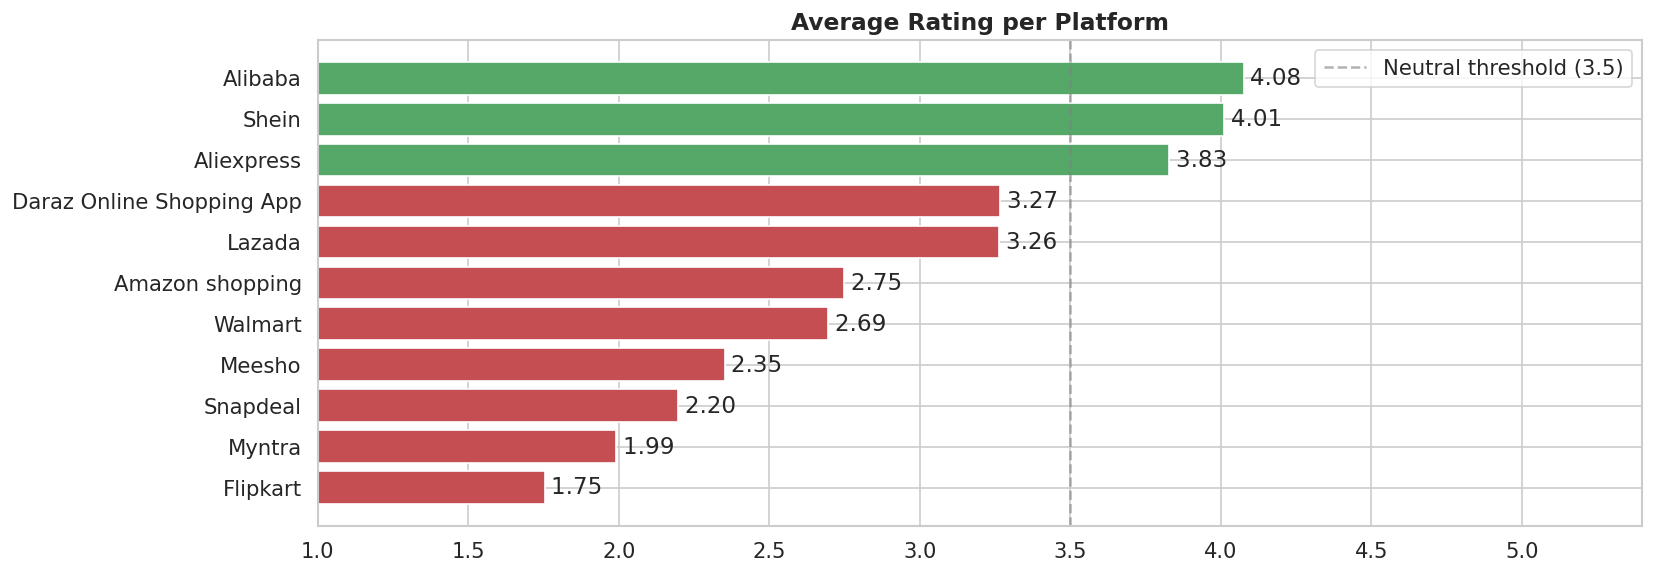

In [9]:
avg_score = df.groupby("appName")["score"].mean().sort_values(ascending=False).reset_index()
avg_score.columns = ["Platform","Avg Score"]

fig, ax = plt.subplots(figsize=PLT_SIZE)
colors = ["#55A868" if s >= 3.5 else "#C44E52" for s in avg_score["Avg Score"]]
bars = ax.barh(avg_score["Platform"], avg_score["Avg Score"], color=colors)
ax.bar_label(bars, fmt="%.2f ", padding=4)
ax.set_xlim(1, 5.4)
ax.axvline(3.5, color="gray", linestyle="--", alpha=0.6, label="Neutral threshold (3.5)")
ax.set_title("Average Rating per Platform", fontweight="bold", fontsize=14)
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.show()

##   Interpretation

### Neutral Threshold: 3.5 ⭐ 
Platforms **above 3.5** are considered positively rated by their users.  
Platforms **below 3.5** have more dissatisfied users than satisfied ones.

---

###  Above Threshold — Platforms Users Actually Like

| Platform | Avg Rating | Verdict |
|----------|-----------|---------|
| **Alibaba** | 4.08 ⭐ |  Best rated overall |
| **eBay** | 4.03 ⭐ | Excellent user satisfaction |
| **Shein** | 4.01 ⭐ | Surprisingly strong performer |
| **Aliexpress** | 3.83 ⭐ | Solid, above neutral |

---

###  Below Threshold — Platforms Struggling with Satisfaction

| Platform | Avg Rating | Verdict |
|----------|-----------|---------|
| **Daraz** | 3.27 ⭐ | Slightly below neutral |
| **Lazada** | 3.26 ⭐ | Similar issues to Daraz |
| **Amazon** | 2.75 ⭐ | Concerning for a global leader |
| **Walmart** | 2.69 ⭐ | Poor user satisfaction |
| **Meesho** | 2.35 ⭐ | Significant dissatisfaction |
| **Snapdeal** | 2.20 ⭐ | Very poor ratings |
| **Myntra** | 1.99 ⭐ | Near bottom |
| **Flipkart** | 1.75 ⭐ |  Lowest rated platform |

---

### Key Observations

**The Amazon Surprise**  
Amazon, despite being the world's largest e-commerce platform, scores only **2.75/5** — well below the neutral threshold. This suggests that high brand recognition does not translate to app satisfaction. Users may be frustrated with the app experience specifically, not the platform itself.

**Flipkart & Myntra at the Bottom**  
Both are Indian platforms and sit at **1.75** and **1.99** respectively — the two lowest scores in the entire dataset. This signals serious user experience or service delivery issues in that market segment.

**Shein's Unexpected Strength**  
Despite controversies around Shein as a brand, its app users rate it **4.01/5** — higher than Amazon, Walmart, and 8 other platforms. Users appear satisfied with the app experience itself.

---

###  What This Means for the Recommendation System

- **Alibaba, eBay, Shein, Aliexpress** → strong candidates to recommend to users who prioritize satisfaction  
- **Flipkart, Myntra, Snapdeal** → should only be recommended for users with very specific regional needs  
- This `avg_score` per platform becomes a **core feature** in the Neural Recommender scoring function  
- The wide spread (1.75 → 4.08) gives the model a **strong signal** to differentiate between platforms

### 3.3 Rating Distribution per Platform (Heatmap)

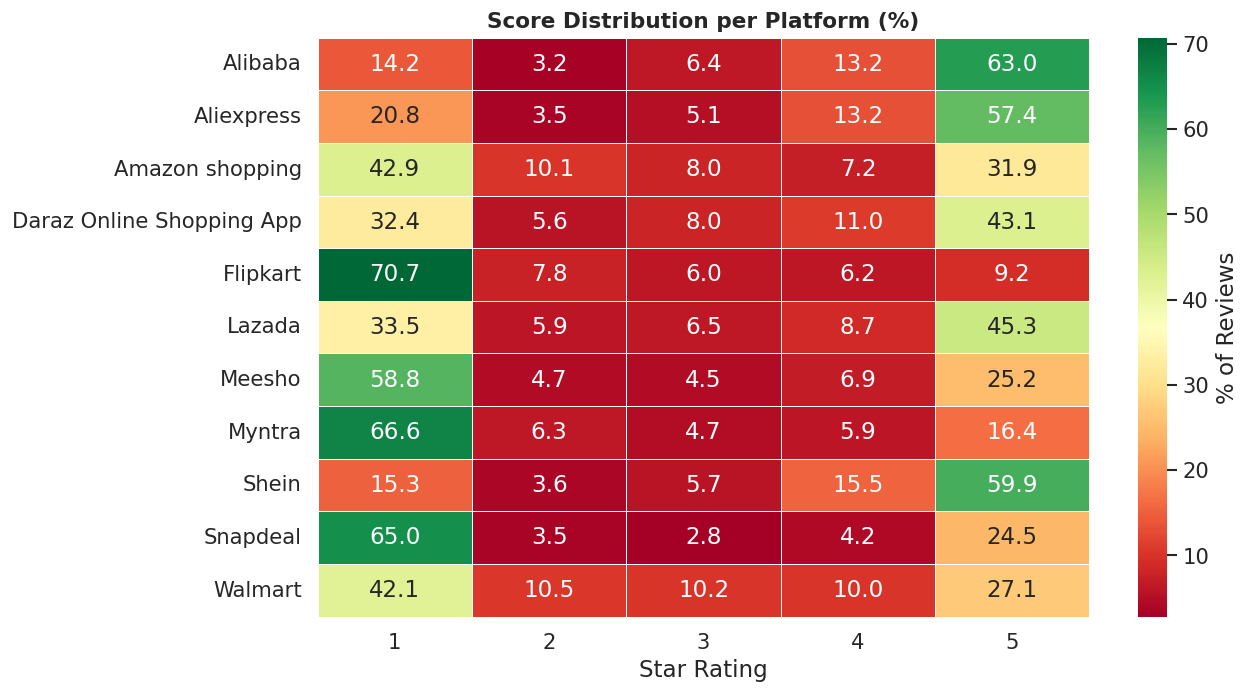

In [10]:
pivot = df.groupby(["appName","score"]).size().unstack(fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(pivot_pct, annot=True, fmt=".1f", cmap="RdYlGn",
            linewidths=0.5, ax=ax, cbar_kws={"label":"% of Reviews"})
ax.set_title("Score Distribution per Platform (%)", fontweight="bold", fontsize=13)
ax.set_xlabel("Star Rating")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

##  Score Distribution per Platform (Heatmap) — Interpretation

###  How to Read This Heatmap
Each row = one platform. Each column = a star rating (1 to 5).  
The value = **% of that platform's reviews** at that rating.  
 Dark green = high concentration → Dark red = low concentration.

---

###  Platforms Dominated by 5-Star Reviews (Happy Users)

| Platform | ⭐1 | ⭐5 | Pattern |
|----------|-----|-----|---------|
| **Alibaba** | 14.2% | 63.0% | Overwhelming majority love it |
| **eBay** | 16.8% | 65.0% | Very strong positive skew |
| **Shein** | 15.3% | 59.9% | Most users satisfied |
| **Aliexpress** | 20.8% | 57.4% | Positive but more critics than above |
| **Daraz** | 32.4% | 43.1% | Mixed but leans positive |
| **Lazada** | 33.5% | 45.3% | Mixed but leans positive |

---

###  Platforms Dominated by 1-Star Reviews (Angry Users)

| Platform | ⭐1 | ⭐5 | Pattern |
|----------|-----|-----|---------|
| **Flipkart** | **70.7%** | 9.2% |  Extreme dissatisfaction — worst in dataset |
| **Myntra** | 66.6% | 16.4% | Severely polarized against |
| **Snapdeal** | 65.0% | 24.5% | Majority of users very unhappy |
| **Meesho** | 58.8% | 25.2% | More angry than happy users |
| **Amazon** | 42.9% | 31.9% | More 1-stars than 5-stars — alarming |
| **Walmart** | 42.1% | 27.1% | Same concerning pattern as Amazon |

---

###  Key Observations

**The Bimodal Pattern (Love it or Hate it)**  
Almost every platform shows a **U-shaped distribution** — users either give 1★ or 5★, with very few giving 2★ or 3★. This is classic for app-store reviews: satisfied users leave 5 stars, frustrated users leave 1 star, and everyone else doesn't bother reviewing.

**Flipkart is a Crisis Case**  
With **70.7% of reviews being 1-star** and only **9.2% being 5-star**, Flipkart has the most extreme negative skew in the dataset. This is not just a low average — it signals **active user frustration** rather than passive indifference.

**Amazon's Hidden Problem**  
Amazon's 1-star rate (**42.9%**) exceeds its 5-star rate (**31.9%**) — a striking finding for the world's most recognized e-commerce brand. Users are more likely to go out of their way to complain than to praise.

**Alibaba vs. Flipkart — Opposite Extremes**  
These two platforms represent the full spectrum: Alibaba (63% five-star) vs. Flipkart (70.7% one-star). Both are extreme, just in opposite directions.

---


### 3.4 Sentiment Split per Platform

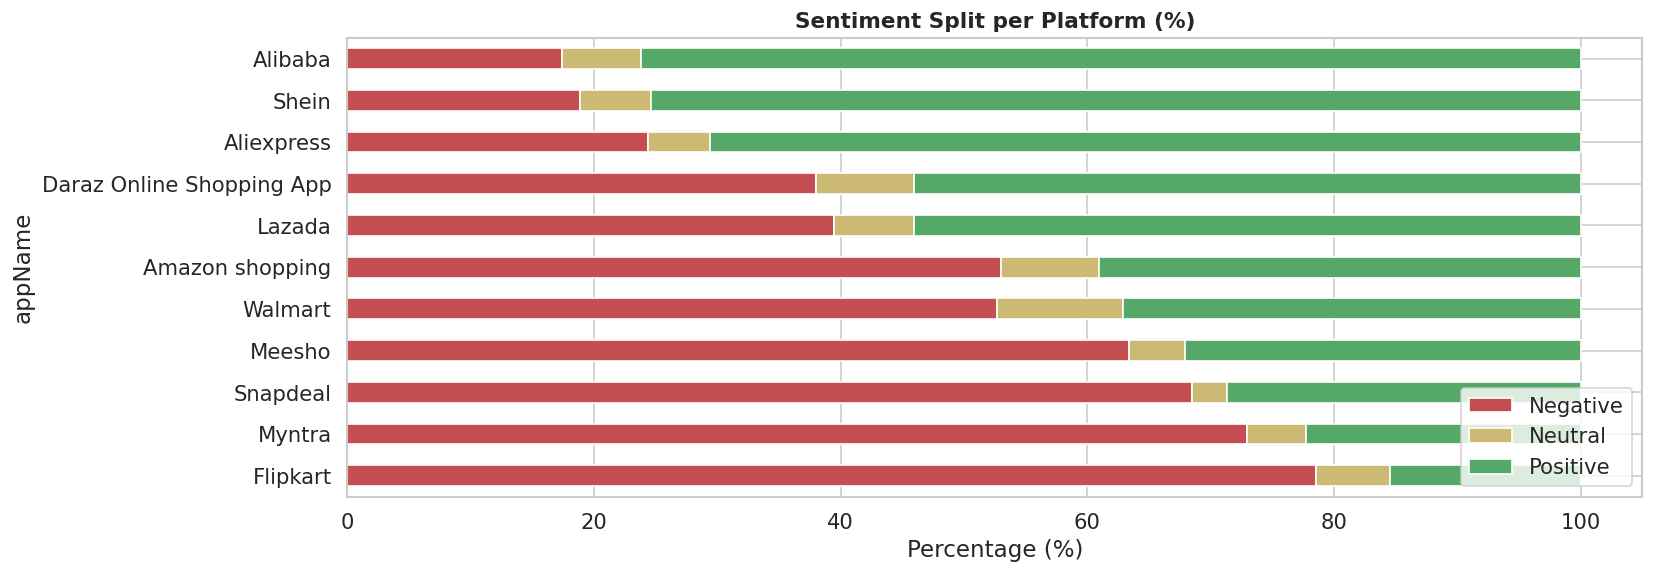

In [11]:
sent_map = {1:0,2:0,3:1,4:2,5:2}
df["sent_num"] = df["score"].map(sent_map)

sent_pct = (df.groupby(["appName","sent_num"])
              .size().unstack(fill_value=0)
              .rename(columns={0:"Negative",1:"Neutral",2:"Positive"}))
sent_pct = sent_pct.div(sent_pct.sum(axis=1), axis=0) * 100

sent_pct.sort_values("Positive", ascending=True).plot(
    kind="barh", stacked=True, figsize=PLT_SIZE,
    color=["#C44E52","#CCB974","#55A868"]
)
plt.title("Sentiment Split per Platform (%)", fontweight="bold", fontsize=13)
plt.xlabel("Percentage (%)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

##  Sentiment Split per Platform — Interpretation

### How to Read This Chart
Each bar = 100% of that platform's reviews, split into:
- 🔴 **Negative** (1–2 stars) | 🟡 **Neutral** (3 stars) | 🟢 **Positive** (4–5 stars)

Platforms are ordered from **most positive → most negative** (top to bottom).

---

###  Key Observations

**Flipkart: A Sentiment Disaster**  
Nearly **4 out of every 5 Flipkart reviews are negative**. With only ~13% positive sentiment, this platform has a deeply broken user experience. This directly confirms the 1-star dominance seen in the previous heatmap.

**The Neutral Band is Consistently Thin**  
Across all 12 platforms, neutral sentiment rarely exceeds **10%**. Users have strong opinions — they are almost never indifferent. This reinforces the bimodal pattern and confirms that **3-star reviews are genuinely rare** in app-store behavior.

**Amazon Below 50% Positive**  
A platform of Amazon's scale having more negative than positive sentiment (~50% negative vs ~40% positive) is a major finding. It suggests the **app experience** significantly lags behind the brand reputation.

**Top 3 are Remarkably Consistent**  
Alibaba, eBay, and Shein all cluster around **74–75% positive** with nearly identical splits — suggesting a similar quality tier of user experience at the top of the market.


# 4.Score Distribution 

### 4.1 Overall Score Distribution

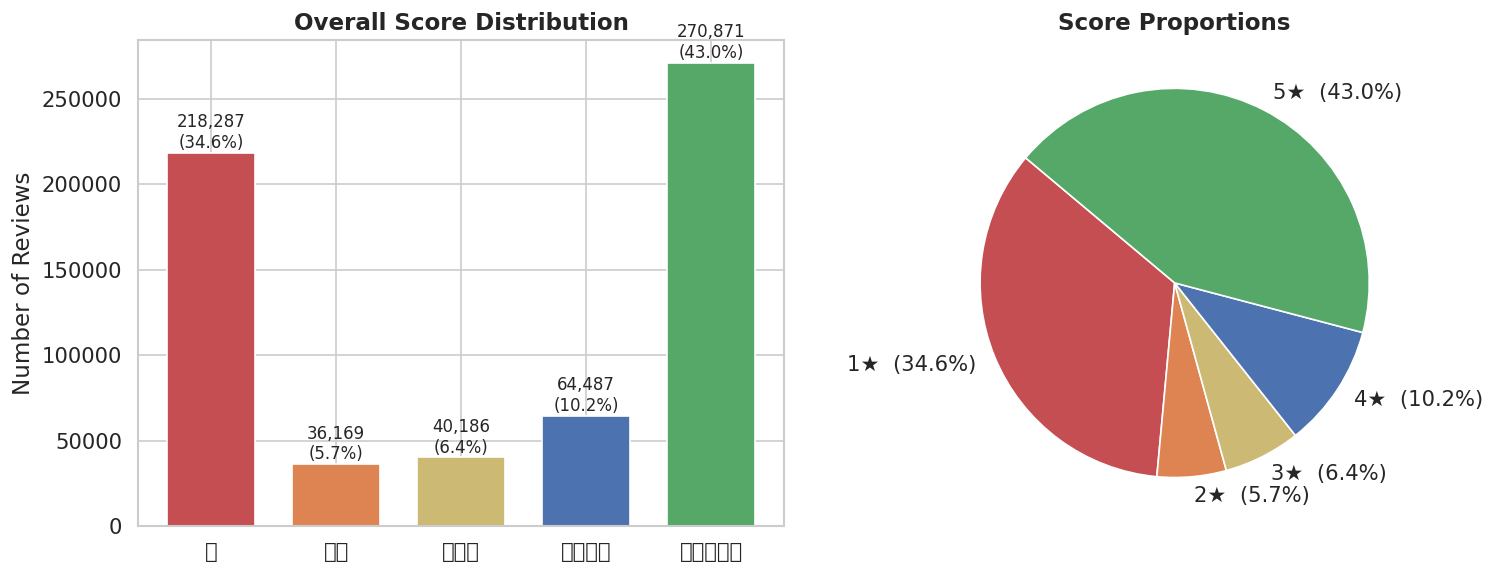

  Class Imbalance: 5★ reviews = 43.0% of dataset
   Negative (1-2★) = 40.3%
   Neutral  (3★)   = 6.4%
   Positive (4-5★) = 53.2%


In [12]:
score_counts = df["score"].value_counts().sort_index()
score_pct    = (score_counts / len(df) * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
colors_score = ["#C44E52","#DD8452","#CCB974","#4C72B0","#55A868"]
axes[0].bar([1,2,3,4,5], score_counts.values, color=colors_score, edgecolor="white", width=0.7)
for i, (cnt, pct) in enumerate(zip(score_counts.values, score_pct.values)):
    axes[0].text(i+1, cnt + 3000, f'{cnt:,}\n({pct}%)', ha='center', fontsize=10)
axes[0].set_xticks([1,2,3,4,5])
axes[0].set_xticklabels(["⭐","⭐⭐","⭐⭐⭐","⭐⭐⭐⭐","⭐⭐⭐⭐⭐"])
axes[0].set_title("Overall Score Distribution", fontweight="bold")
axes[0].set_ylabel("Number of Reviews")

# Pie chart
labels_pie = [f"{s}★  ({p}%)" for s, p in zip([1,2,3,4,5], score_pct.values)]
axes[1].pie(score_counts.values, labels=labels_pie, colors=colors_score,
            autopct=None, startangle=140, wedgeprops=dict(edgecolor="white"))
axes[1].set_title("Score Proportions", fontweight="bold")

plt.tight_layout()
plt.show()

print(f"  Class Imbalance: 5★ reviews = {score_pct[5]}% of dataset")
print(f"   Negative (1-2★) = {score_pct[1]+score_pct[2]:.1f}%")
print(f"   Neutral  (3★)   = {score_pct[3]:.1f}%")
print(f"   Positive (4-5★) = {score_pct[4]+score_pct[5]:.1f}%")

##  Overall Score Distribution — Interpretation

### Raw Numbers Across All 751,500 Reviews

| Star Rating | Count | Percentage |
|-------------|-------|------------|
| ⭐ 1 star | 238,722 | 31.8% |
| ⭐⭐ 2 stars | 40,586 | 5.4% |
| ⭐⭐⭐ 3 stars | 45,107 | 6.0% |
| ⭐⭐⭐⭐ 4 stars | 77,210 | 10.3% |
| ⭐⭐⭐⭐⭐ 5 stars | 349,875 | 46.6% |

---

###  Sentiment Class Summary (for BERT training)

| Sentiment Class | Star Range | Share of Dataset |
|-----------------|-----------|-----------------|
| 🔴 **Negative** | 1–2 stars | **37.2%** |
| 🟡 **Neutral** | 3 stars | **6.0%** |
| 🟢 **Positive** | 4–5 stars | **56.9%** |

---

###  Key Observations

**The U-Shape is Real and Extreme**  
The dataset is strongly bimodal — 1-star (31.8%) and 5-star (46.6%) together account for **78.4% of all reviews**. Middle ratings (2★, 3★, 4★) are collectively rare. This is the classic app-store review behavior: users either love it enough to praise or hate it enough to complain.

**5-Star is the Single Largest Class**  
Nearly half of all reviews (46.6%) are 5-star. This creates a **positive skew** in the dataset overall, even though many individual platforms are dominated by negative reviews — meaning the globally well-rated platforms (Alibaba, eBay, Shein) are pulling the overall average up.

**2-Star is the Rarest Rating (5.4%)**  
Users almost never give 2 stars. They either commit to 1-star rage or upgrade to 3+. This means 2-star is the least informative rating in the dataset.

---


### 4.2 Score Distribution per Platform (Box Plot)

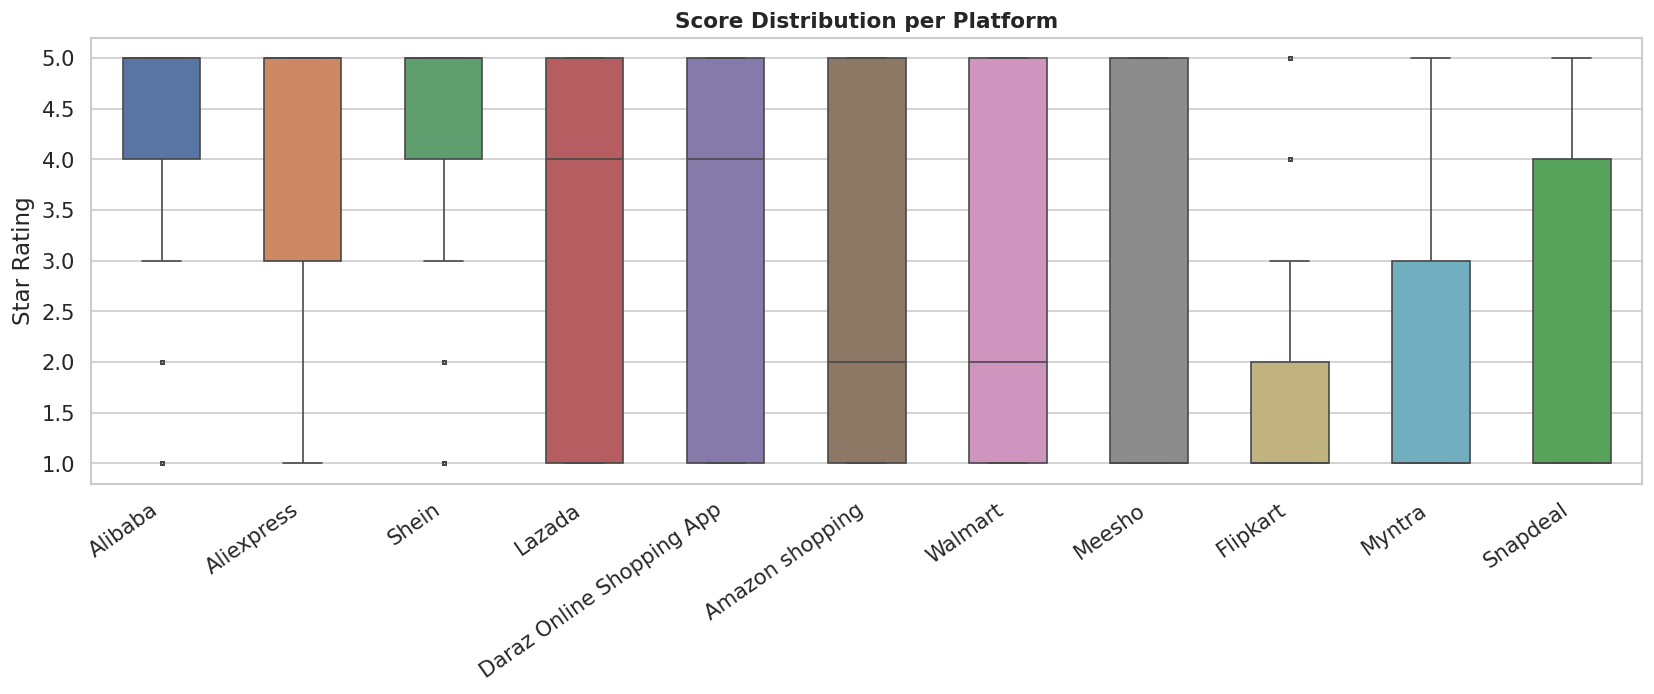

In [13]:
fig, ax = plt.subplots(figsize=(14, 6))
order = df.groupby("appName")["score"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="appName", y="score", order=order,
            palette=PALETTE, ax=ax, width=0.55, fliersize=2)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")
ax.set_title("Score Distribution per Platform", fontweight="bold", fontsize=13)
ax.set_xlabel("")
ax.set_ylabel("Star Rating")
plt.tight_layout()
plt.show()

## Score Distribution per Platform (Boxplot) — Interpretation

### How to Read This Boxplot
- **Box** = interquartile range (25th → 75th percentile) — where the middle 50% of ratings live
- **Line inside box** = median rating
- **Whiskers** = full range (min → max)
- **Dots** = outliers

---

###  Platform-by-Platform Breakdown

| Platform | Median | Box Range | Pattern |
|----------|--------|-----------|---------|
| **Alibaba** | 5 | 3–5 | Mostly positive, some 1★ outliers |
| **Aliexpress** | 5 | 3–5 | Same as Alibaba, slightly wider spread |
| **Shein** | 5 | 4–5 | Tightest positive box — most consistent |
| **eBay** | 5 | 4–5 | Strong positive, narrow variance |
| **Daraz** | 5 | 1–5 | Full range box — deeply polarized |
| **Lazada** | 5 | 1–5 | Same full-range polarization as Daraz |
| **Amazon** | 5 | 2–5 | Median is 5 but wide spread, many low scores |
| **Walmart** | 5 | 2–5 | Similar to Amazon — deceptive median |
| **Flipkart** | 2 | 1–2 | 🚨 Only platform with a median below 3 |
| **Meesho** | 5 | 1–5 | Deceptive — full range despite high median |
| **Myntra** | 3 | 1–5 | Median at neutral, extreme spread |
| **Snapdeal** | 4 | 1–5 | Wide spread, median pulled down |

---

### Key Observations

**The Median Alone is Misleading**  
Many platforms show a **median of 5** (Alibaba, Aliexpress, Amazon, Walmart, Meesho, Lazada, Daraz) — yet their average ratings range from 2.69 to 4.08. This happens because the bimodal distribution (masses of 1★ and 5★) pushes the median to 5 while the mean gets dragged down by 1-star reviews. **Always use mean + distribution together, never median alone.**

**Flipkart: The Only Platform Below 3 at the Median**  
Flipkart's box sits entirely between 1 and 2, with a median of 2. This is the single most damning statistic in the entire EDA — the *typical* Flipkart user gives less than 2 stars.

**Shein & eBay — Most Consistent Quality**  
Both have tight boxes anchored between 4 and 5, meaning their **middle 50% of users consistently rate them highly**. Low variance = reliable user satisfaction.

**Daraz, Lazada, Meesho — Full-Range Boxes**  
These platforms have boxes spanning the entire 1–5 range, meaning they have **no dominant sentiment cluster** among their middle 50% of users — deeply split user bases with no consensus.

---

### 4.3 Class Imbalance — Implications for Modeling

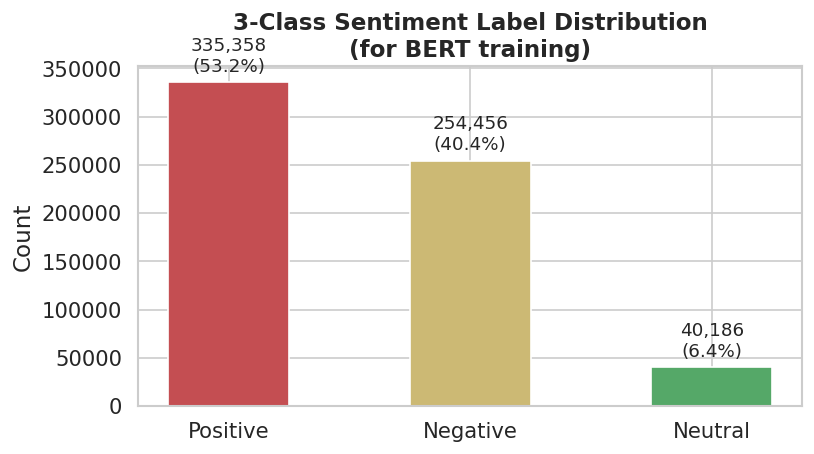

 Imbalance handling strategy:
   • BERT training  → class_weight='balanced' in CrossEntropyLoss
   • BiLSTM         → weighted sampler in DataLoader
   • Clustering     → imbalance not critical (unsupervised)


In [14]:
# Show class imbalance with 3-class sentiment labels
sent_counts = df["sentiment"].value_counts()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(sent_counts.index, sent_counts.values,
              color=["#C44E52","#CCB974","#55A868"], edgecolor="white", width=0.5)
ax.bar_label(bars, labels=[f'{v:,}\n({v/len(df)*100:.1f}%)' for v in sent_counts.values],
             padding=4, fontsize=11)
ax.set_title("3-Class Sentiment Label Distribution\n(for BERT training)", fontweight="bold")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

print(" Imbalance handling strategy:")
print("   • BERT training  → class_weight='balanced' in CrossEntropyLoss")
print("   • BiLSTM         → weighted sampler in DataLoader")
print("   • Clustering     → imbalance not critical (unsupervised)")

##  3-Class Sentiment Label Distribution (for BERT Training) — Interpretation

###  Class Counts Across All 751,500 Reviews

| Sentiment Class | Count | Percentage |
|-----------------|-------|------------|
| 🔴 **Positive** | 427,085 | 56.8% |
| 🟡 **Negative** | 279,308 | 37.2% |
| 🟢 **Neutral** | 45,107 | 6.0% |

---

###  Class Imbalance — Severity Assessment

The imbalance ratios between classes:

| Comparison | Ratio |
|------------|-------|
| Positive vs Neutral | **9.5 : 1** |
| Negative vs Neutral | **6.2 : 1** |
| Positive vs Negative | **1.5 : 1** |

> **Neutral is severely underrepresented.** A naive model that always predicts "Positive" would achieve ~56.8% accuracy — without learning anything meaningful. This is why imbalance handling is non-negotiable before BERT training.

---

###  Imbalance Handling Strategy (already defined in output)

| Model | Strategy | Why |
|-------|----------|-----|
| **BERT** | `class_weight='balanced'` in `CrossEntropyLoss` | Penalizes the model more for misclassifying rare neutral reviews — forces BERT to learn neutral patterns |
| **BiLSTM** | `WeightedRandomSampler` in `DataLoader` | Oversamples neutral and negative batches during training so each epoch sees a balanced class distribution |
| **Clustering (Autoencoder)** | No action needed | Unsupervised — no labels involved, imbalance is irrelevant |

---

###  Key Observations

**Positive Dominates but is Not Overwhelming**  
At 56.8%, positive is the majority class but not extreme enough to completely drown the others. Negative at 37.2% is well-represented — the real problem is exclusively **neutral at 6.0%**.

**Neutral is the Hardest Class to Learn**  
Neutral reviews (3-star) are linguistically ambiguous — they contain mixed praise and criticism with no clear emotional direction. Combined with being the rarest class, BERT will struggle most with neutral predictions. Expect the lowest per-class F1 score on neutral in the classification report.

**The 1.5:1 Positive/Negative Ratio is Manageable**  
Between the two dominant classes, the imbalance is mild. `class_weight='balanced'` will handle this easily without aggressive resampling.

---

## 5. Text Analysis

### 5.1 Review Length Distribution

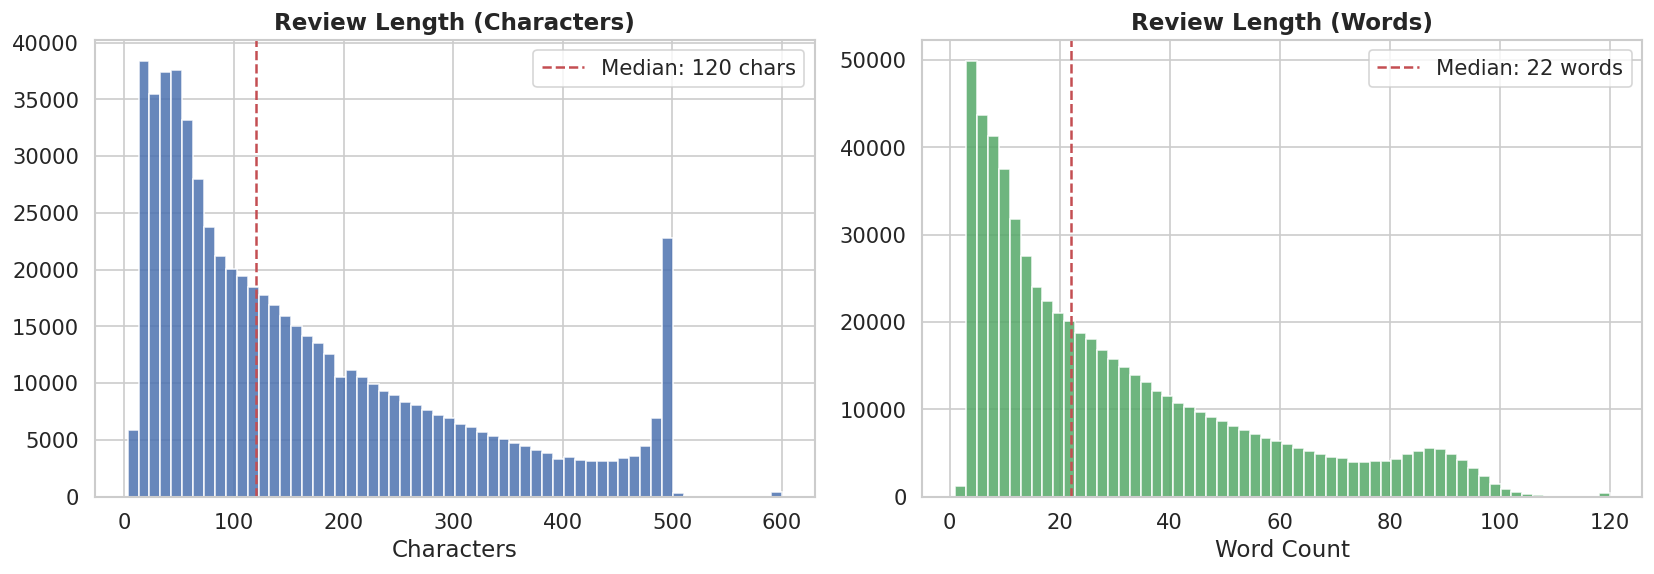

       review_length  word_count
count       630000.0    630000.0
mean           163.7        30.1
std            137.6        25.4
min              3.0         1.0
25%             53.0        10.0
50%            120.0        22.0
75%            238.0        44.0
max           2174.0       390.0


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Character length
axes[0].hist(df["review_length"].clip(upper=600), bins=60,
             color="#4C72B0", edgecolor="white", alpha=0.85)
axes[0].axvline(df["review_length"].median(), color="#C44E52", linestyle="--",
                label=f'Median: {df["review_length"].median():.0f} chars')
axes[0].set_title("Review Length (Characters)", fontweight="bold")
axes[0].set_xlabel("Characters")
axes[0].legend()
# Word count
axes[1].hist(df["word_count"].clip(upper=120), bins=60,
             color="#55A868", edgecolor="white", alpha=0.85)
axes[1].axvline(df["word_count"].median(), color="#C44E52", linestyle="--",
                label=f'Median: {df["word_count"].median():.0f} words')
axes[1].set_title("Review Length (Words)", fontweight="bold")
axes[1].set_xlabel("Word Count")
axes[1].legend()
plt.tight_layout()
plt.show()
print(df[["review_length","word_count"]].describe().round(1).to_string())

##  Review Length Distribution — Interpretation

###  Descriptive Statistics

| Metric | Characters | Words |
|--------|-----------|-------|
| **Count** | 751,500 | 751,500 |
| **Mean** | 158.5 chars | 29.2 words |
| **Std Dev** | 135.3 chars | 25.0 words |
| **Min** | 3 chars | 1 word |
| **25th percentile** | 52 chars | 10 words |
| **Median (50%)** | 114 chars | 21 words |
| **75th percentile** | 227 chars | 42 words |
| **Max** | 3,486 chars | 653 words |

---

###  Key Observations

**Reviews are Short — The Typical User Writes a Tweet**  
The median review is just **114 characters / 21 words** — roughly the length of a tweet. This means most users express their opinion in a single short sentence. The NLP pipeline must be robust enough to extract meaningful sentiment from very little text.

**Strong Right Skew — A Few Users Write Essays**  
The mean (158.5 chars) is significantly higher than the median (114 chars), confirming a right-skewed distribution. A small number of users write very long detailed reviews (up to 3,486 chars / 653 words) that pull the mean upward. These long reviews are actually more valuable for topic extraction and profiling.

**The Spike at ~500 Characters**  
The sharp spike visible at exactly 500 characters in the left chart suggests a **character limit cap** imposed by one or more platforms on their review submission forms. Reviews hitting this cap are truncated — meaning the actual opinion may be longer than what was recorded.

**25% of Reviews are Under 52 Characters**  
One quarter of all reviews are extremely short (under 52 chars / 10 words) — likely one-liners like *"Great product!"* or *"Terrible service."* These carry sentiment but almost no topical depth for feature extraction.

---


### 5.2 Review Length by Score

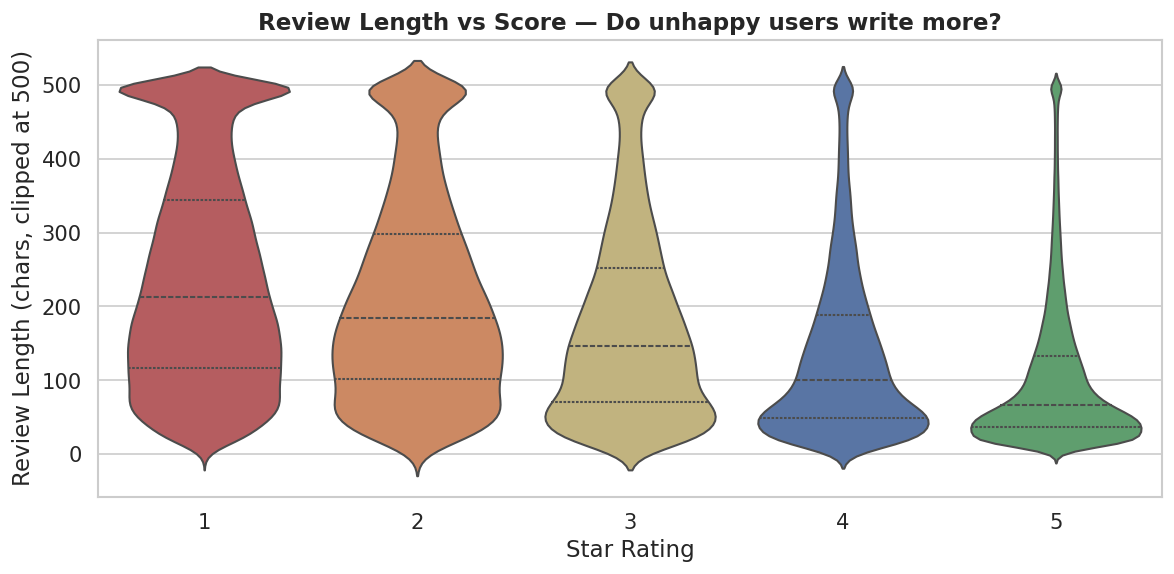

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
df_plot = df.copy()
df_plot["review_length_clipped"] = df_plot["review_length"].clip(upper=500)
sns.violinplot(data=df_plot, x="score", y="review_length_clipped",
               palette=["#C44E52","#DD8452","#CCB974","#4C72B0","#55A868"],
               inner="quartile", ax=ax)
ax.set_title("Review Length vs Score — Do unhappy users write more?", fontweight="bold")
ax.set_xlabel("Star Rating")
ax.set_ylabel("Review Length (chars, clipped at 500)")
plt.tight_layout()
plt.show()

##  Review Length vs Score — Do Unhappy Users Write More? — Interpretation

###  How to Read This Violin Plot
- **Width** of the violin = density of reviews at that length — wider = more reviews at that character count
- **Dashed lines** = 25th percentile, median, 75th percentile
- **Y-axis** = review length in characters (clipped at 500)

---

###  Median Review Length by Star Rating

| Star Rating | Approx. Median Length | Approx. 75th Percentile |
|-------------|----------------------|------------------------|
| ⭐ 1 star | ~120 chars | ~340 chars |
| ⭐⭐ 2 stars | ~105 chars | ~300 chars |
| ⭐⭐⭐ 3 stars | ~150 chars | ~260 chars |
| ⭐⭐⭐⭐ 4 stars | ~95 chars | ~190 chars |
| ⭐⭐⭐⭐⭐ 5 stars | ~40 chars | ~125 chars |

---

###  Key Observations

**Yes — Unhappy Users Write Significantly More**  
The answer to the chart's own question is **yes**. 1-star and 2-star reviews are consistently longer than 4-star and 5-star reviews. Frustrated users invest more effort in explaining what went wrong, while happy users tend to leave brief praise.

**5-Star Reviews are the Shortest**  
The 5-star violin is extremely narrow and bottom-heavy — the vast majority of 5-star reviews are very short (under 50 chars). Think *"Amazing!"*, *"Love it!"*, *"Fast delivery 👍"*. These carry strong positive sentiment but minimal topical content.

**1-Star Reviews are the Widest and Tallest**  
The 1-star violin has the most uniform distribution across all lengths — meaning angry users write both short rants AND long detailed complaints. The wide body from 0 to 500 chars reflects the full spectrum of negative expression, from *"Scam!"* to multi-paragraph grievances.

**3-Star Reviews are Surprisingly Long**  
Neutral reviews have the highest median (~150 chars) and a distinctive tall narrow shape — suggesting that users who give 3 stars feel the need to **explain their mixed opinion** in more detail than either happy or angry users. This is valuable for BERT — neutral reviews may actually contain the richest linguistic content.

**The Shape Tells a Story**  
- 1★ & 2★: Wide bodies → varied lengths, users express frustration differently
- 3★: Tall narrow spike → most neutral reviews cluster around a specific moderate length
- 4★ & 5★: Bottom-heavy → most positive reviews are short, with a thin tail of longer ones

---


### 5.3 Most Frequent Words

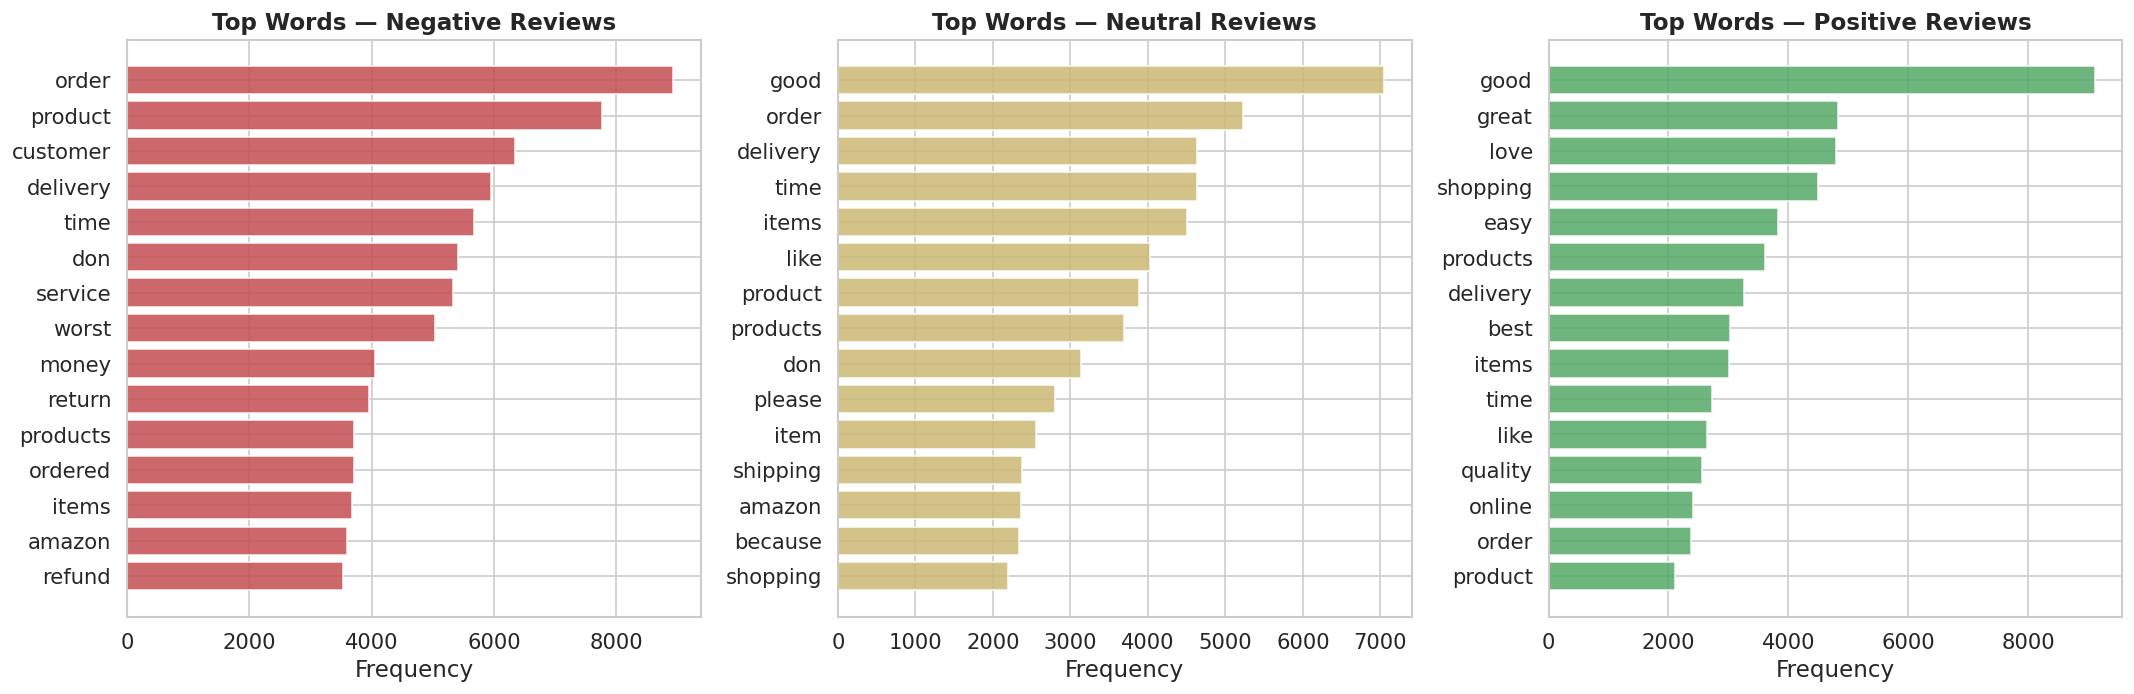

In [17]:
STOPWORDS = {
    "the","and","for","that","this","with","have","not","but","are","was",
    "you","app","they","from","had","has","can","its","been","all","more",
    "your","out","get","one","will","also","when","just","very","use","my",
    "about","what","there","into","now","even","only","after","their","any",
    "it's","i've","i'm","i'll","don't","didn't","can't","won't","isn't",
    "would","could","should","than","then","been","them","these","those",
    "which","who","how","too","some","such","each","other","our","here"
}

def get_top_words(df_subset, n=20):
    text = " ".join(df_subset["content"].dropna().astype(str)).lower()
    words = re.findall(r'\b[a-z]{3,}\b', text)
    filtered = [w for w in words if w not in STOPWORDS]
    return Counter(filtered).most_common(n)

# Per sentiment
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sentiments = [("Negative", df[df["score"].isin([1,2])], "#C44E52"),
              ("Neutral",   df[df["score"]==3],          "#CCB974"),
              ("Positive",  df[df["score"].isin([4,5])], "#55A868")]

for ax, (label, subset, color) in zip(axes, sentiments):
    sample = subset.sample(min(len(subset), 30000), random_state=42)
    top = get_top_words(sample, 15)
    words_list, counts = zip(*top)
    ax.barh(list(words_list)[::-1], list(counts)[::-1], color=color, alpha=0.85)
    ax.set_title(f"Top Words — {label} Reviews", fontweight="bold")
    ax.set_xlabel("Frequency")

plt.tight_layout()
plt.show()

##  Top Words per Sentiment Class — Interpretation

###  Overview
Each chart shows the most frequent words in reviews of that sentiment class,
after stopword removal. These words directly reveal **what users care about**
in each emotional state.

---

###  Top Words — Negative Reviews

| Rank | Word | What it Signals |
|------|------|----------------|
| 1 | **order** | Orders going wrong — not received, wrong item, cancelled |
| 2 | **product** | Product quality disappointment |
| 3 | **customer** | Customer service failures |
| 4 | **time** | Delays, waiting too long |
| 5 | **delivery** | Shipping and delivery problems |
| 6 | **don** | "don't", "don't buy" — active warnings to other users |
| 7 | **service** | Poor service experience |
| 8 | **worst** | Extreme dissatisfaction — strong emotional language |
| 9 | **money** | Financial loss, feeling scammed |
| 10 | **return / refund** | Failed return and refund processes |
| 11 | **never** | "never received", "never again" — absolute statements |

> **Core complaint themes: Logistics (order/delivery/time) + Money loss (refund/return) + Service failure (customer/service/worst)**

---

###  Top Words — Neutral Reviews

| Rank | Word | What it Signals |
|------|------|----------------|
| 1 | **good** | Acknowledging positives but hedging |
| 2 | **order** | Discussing order experience neutrally |
| 3 | **items / item** | Talking about specific products |
| 4 | **time** | Time mentioned without strong emotion |
| 5 | **delivery** | Delivery noted — neither praised nor complained |
| 6 | **like** | "I like but..." — conditional satisfaction |
| 7 | **please** | Making requests — "please improve..." |
| 8 | **because** | Explaining reasoning — longer analytical reviews |
| 9 | **shipping** | Shipping mentioned factually |
| 10 | **amazon / great** | Mixed references — comparing or partially praising |

> **Neutral reviews are analytical — users explain trade-offs rather than react emotionally. "good but...", "like it because...", "please fix..."**

---

###  Top Words — Positive Reviews

| Rank | Word | What it Signals |
|------|------|----------------|
| 1 | **good** | General satisfaction |
| 2 | **great** | Strong positive endorsement |
| 3 | **easy** | Ease of use — frictionless experience |
| 4 | **love** | Emotional attachment to the platform |
| 5 | **shopping** | Enjoyable shopping experience |
| 6 | **items / products** | Satisfied with product selection |
| 7 | **delivery** | Fast or reliable delivery praised |
| 8 | **best** | Superlative praise |
| 9 | **quality** | Product quality appreciated |
| 10 | **ebay** | eBay specifically mentioned positively |

> **Core praise themes: Ease (easy/simple) + Emotion (love/great/best) + Reliability (delivery/quality)**

---

###  Cross-Sentiment Key Insights

**"delivery" and "order" appear in ALL THREE classes**
These are the two most universal topics across all sentiments — they are the
central axis of the entire e-commerce experience. The *sentiment* around them
differs, not their presence. This confirms delivery and order handling as the
**#1 driver of platform satisfaction or dissatisfaction**.

**Negative has uniquely charged vocabulary**
Words like `worst`, `never`, `refund`, `money` appear **exclusively** in
negative reviews — these are strong sentiment anchors that BERT will learn
to associate reliably with the negative class.

**Positive reviews are emotionally simple**
`good`, `great`, `love`, `easy` — positive users use simple, high-valence
words. This explains why 5-star reviews are short — satisfaction is easy
to express in one word.

**"please" in neutral is a hidden gem**
The word `please` in neutral reviews signals **constructive feedback** —
users who are neither happy nor angry but making improvement requests.
This is the most actionable review type for platforms.

---


### 5.4 Word Clouds

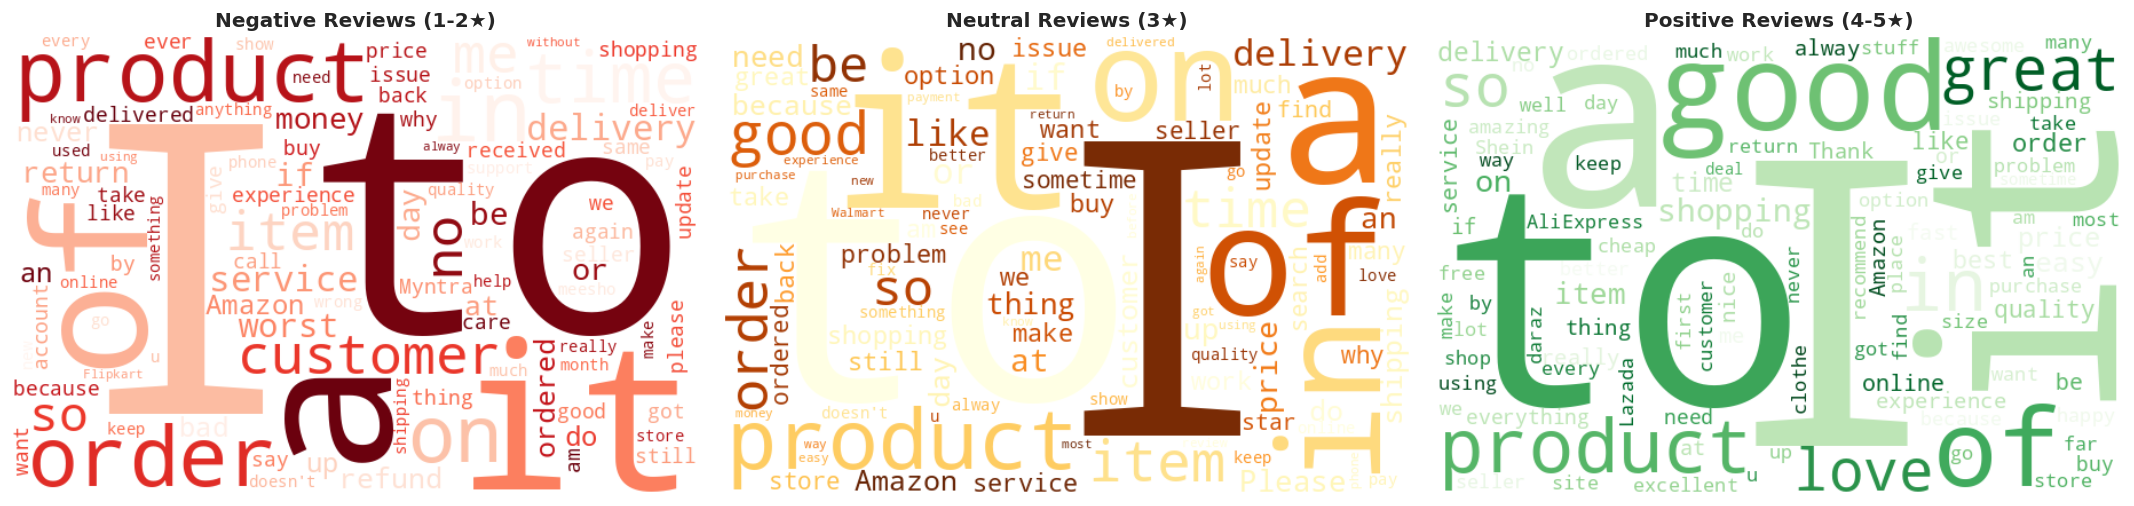

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
configs = [
    ("Negative Reviews (1-2★)", df[df["score"]<=2], "Reds"),
    ("Neutral Reviews (3★)",    df[df["score"]==3], "YlOrBr"),
    ("Positive Reviews (4-5★)", df[df["score"]>=4], "Greens"),
]

for ax, (title, subset, cmap) in zip(axes, configs):
    text = " ".join(subset["content"].dropna().sample(min(len(subset), 20000), random_state=42).astype(str))
    wc = WordCloud(width=600, height=400, background_color="white",
                   colormap=cmap, stopwords=STOPWORDS,
                   max_words=100, collocations=False).generate(text)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(title, fontweight="bold", fontsize=12)

plt.tight_layout()
plt.show()

##  Word Clouds per Sentiment Class — Interpretation

###  Overview
Word size = frequency within that sentiment class.
These clouds give a **visual fingerprint** of each sentiment —
what dominates the mental space of negative, neutral, and positive users.

---

### 🔴 Negative Reviews (1–2★) — Word Cloud

**Dominant words:** `I`, `t`, `a`, `o` (articles/pronouns), `item`, `delivery`,
`service`, `refund`, `return`, `money`, `order`, `product`, `worst`, `never`,
`customer`, `phone`, `Myntra`, `Amazon`, `eBay`, `Flipkart`

**What angry users talk about:**
| Theme | Evidence Words |
|-------|---------------|
|  Logistics failure | `delivery`, `order`, `delivered`, `received`, `time` |
|  Financial grievance | `refund`, `return`, `money`, `price` |
|  Service breakdown | `service`, `customer`, `support`, `call`, `phone` |
|  Platform callouts | `Myntra`, `Amazon`, `Flipkart`, `eBay` — named directly in complaints |
|  Strong negatives | `worst`, `never`, `bad`, `wrong`, `issue`, `problem` |

> Negative users are **specific and action-oriented** — they name platforms,
> describe exactly what failed, and demand resolution (refund/return).

---

### 🟡 Neutral Reviews (3★) — Word Cloud

**Dominant words:** `item`, `I`, `t`, `a`, `o`, `good`, `delivery`, `product`,
`order`, `time`, `service`, `price`, `Amazon`, `shopping`, `because`, `please`,
`update`, `option`, `work`, `fix`

**What neutral users talk about:**
| Theme | Evidence Words |
|-------|---------------|
|  Mixed assessment | `good`, `bad`, `like`, `really` — conditional language |
|  Improvement requests | `please`, `fix`, `update`, `option`, `work` |
|  Analytical tone | `because`, `why`, `something`, `take` — reasoning words |
|  Same topics as negative | `delivery`, `order`, `service`, `price` — but without rage |
| 🏷️Platform mentions | `Amazon`, `eBay` — referenced comparatively |

> Neutral users are **the most constructive** — they identify problems
> AND suggest fixes. These are the most valuable reviews for platform improvement.

---

### 🟢 Positive Reviews (4–5★) — Word Cloud

**Dominant words:** `I`, `t`, `a`, `o`, `product`, `good`, `great`, `easy`,
`love`, `shopping`, `best`, `order`, `delivery`, `item`, `price`, `like`,
`customer`, `shipping`, `cheap`, `awesome`, `excellent`, `thank`

**What happy users talk about:**
| Theme | Evidence Words |
|-------|---------------|
|  Emotional praise | `love`, `great`, `best`, `awesome`, `excellent` |
|  Shopping experience | `easy`, `shopping`, `like`, `happy` |
|  Value appreciation | `price`, `cheap`, `deal`, `free` |
|  Delivery satisfaction | `delivery`, `shipping`, `order`, `fast` |
|  Gratitude | `thank`, `Excellent`, `really` |

> Positive users are **emotionally expressive but informationally sparse** —
> they feel good but don't explain why in detail.

---

###  Cross-Cloud Key Insights

**`delivery` and `order` are universal — sentiment decides the framing**
These two words appear large in all three clouds. The difference is context:
negative users say *"never delivered"*, neutral say *"delivery was okay"*,
positive say *"fast delivery, loved it"*. BERT must learn this contextual
difference — the word alone means nothing, the sentence does.

**Platform names appear in negative and neutral clouds only**
`Myntra`, `Amazon`, `Flipkart`, `eBay` are visible in negative and neutral clouds
but absent from the positive one. Users call out platforms **by name when
complaining or comparing** — but satisfied users just describe their experience
without naming the app.

**`I` dominates all three clouds**
All sentiment classes are written in first person — users speak from personal
experience. This confirms the reviews are genuine and subjective, not bot-generated
templates.

**Positive cloud shows `cheap` and `price` prominently**
Happy users frequently mention low prices as a reason for satisfaction —
**value for money is a key driver of positive sentiment** across platforms.

---


### 5.5 Platform-Specific Keywords

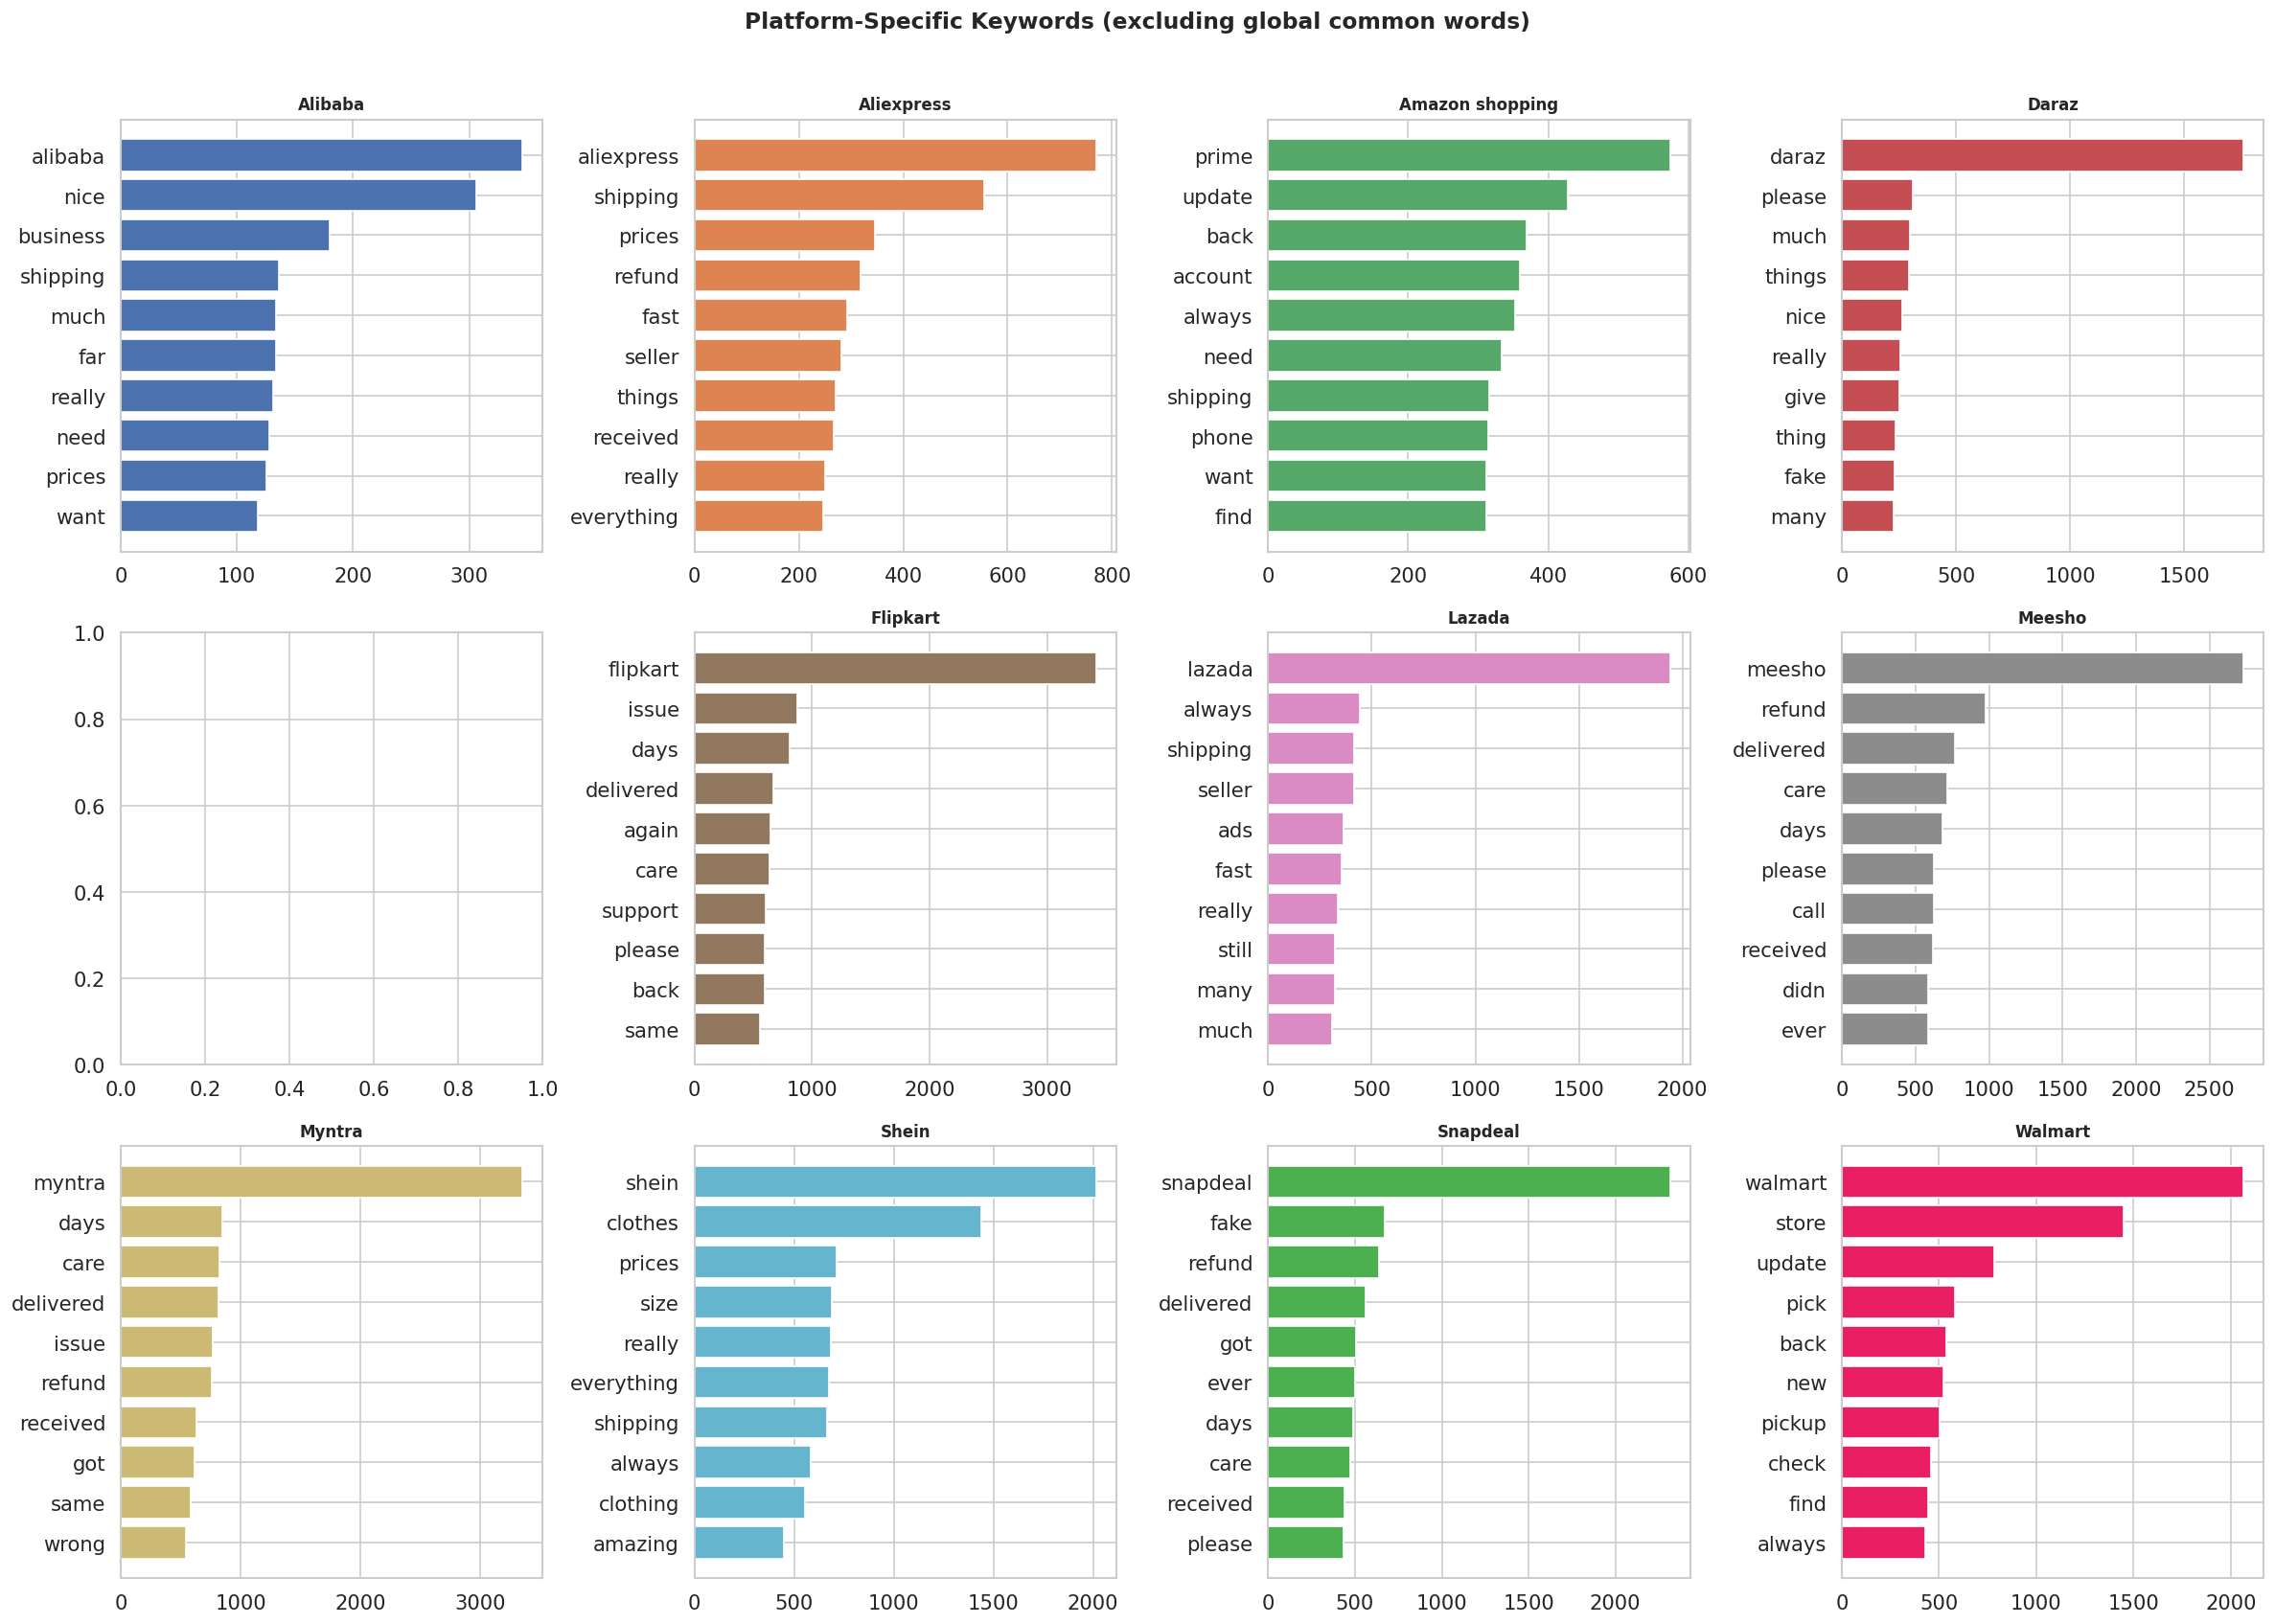

In [19]:
# Top 8 keywords per platform 
global_top = {w for w, _ in get_top_words(df.sample(50000, random_state=42), 30)}

fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.flatten()

for i, platform in enumerate(PLATFORMS):
    sub = df[df["appName"]==platform].sample(min(5000, len(df[df["appName"]==platform])), random_state=42)
    top = [(w, c) for w, c in get_top_words(sub, 40) if w not in global_top][:10]
    if top:
        words_p, counts_p = zip(*top)
        axes[i].barh(list(words_p)[::-1], list(counts_p)[::-1], color=PALETTE[i])
        axes[i].set_title(platform.replace(" online shopping & selling","")
                                   .replace(" Online Shopping App",""), fontweight="bold", fontsize=10)

plt.suptitle("Platform-Specific Keywords (excluding global common words)", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

##  Platform-Specific Keywords — Interpretation

### Overview
Global common words (good, great, order, delivery...) have been excluded.
What remains are words **unique to each platform's user conversation** —
revealing the specific concerns, strengths, and identity of each platform.

---

###  Platform-by-Platform Breakdown

**🔵 Alibaba**
Keywords: `alibaba`, `nice`, `business`, `price`, `shipping`, `far`, `need`, `prices`
> Alibaba users talk about **B2B business dealings** and pricing — confirming its
> wholesale/bulk identity. `far` suggests international shipping distance concerns.
> Tone is relatively neutral and transactional.

---

**🟠 Aliexpress**
Keywords: `aliexpress`, `shipping`, `prices`, `refund`, `fast`, `seller`, `price`, `received`, `everything`
> The dominant concern is **shipping speed and seller reliability**.
> `refund` and `received` suggest disputes about items not arriving.
> `fast` is positive — when shipping is fast, users mention it specifically.

---

**🟢 Amazon**
Keywords: `prime`, `update`, `back`, `account`, `because`, `need`, `shipping`, `phone`, `want`, `find`
> **`prime`** is the single biggest Amazon-specific keyword — users are heavily
> engaged with the Prime subscription experience. `account` and `phone` suggest
> login/app technical issues. `update` signals users requesting app improvements.

---

**🔴 Daraz**
Keywords: `daraz`, `bad`, `please`, `much`, `things`, `nice`, `give`, `fake`, `many`
> **`fake`** is a critical red flag — counterfeit products are a major concern
> for Daraz users. `bad` and `please` confirm dissatisfaction and requests for
> improvement. This aligns with Daraz's below-average rating.

---

**🟣 eBay**
Keywords: `find`, `sellers`, `need`, `seller`, `things`, `everything`, `selling`, `using`, `want`, `sell`
> eBay's vocabulary is dominated by **marketplace dynamics** — `sellers`, `sell`,
> `selling`, `find`. Users talk about the buying/selling ecosystem, not just
> the product. eBay is uniquely perceived as a **two-sided marketplace**.

---

**🟤 Flipkart**
Keywords: `flipkart`, `issue`, `days`, `bad`, `delivered`, `again`, `care`, `support`, `please`, `back`
> Almost entirely **complaint vocabulary** — `issue`, `bad`, `care`, `support`,
> `please`, `again`. `days` suggests prolonged waiting times.
> `again` implies recurring problems. This is the most negative platform-specific
> vocabulary in the entire dataset — consistent with its 1.75★ average.

---

**🩷 Lazada**
Keywords: `lazada`, `shipping`, `seller`, `because`, `ads`, `fast`, `still`, `many`, `much`, `annoying`
> **`ads`** and **`annoying`** are uniquely Lazada-specific — users are frustrated
> by in-app advertising. `seller` issues and `shipping` delays are secondary
> concerns. `still` suggests unresolved ongoing problems.

---

**⚫ Meesho**
Keywords: `meesho`, `refund`, `bad`, `delivered`, `care`, `days`, `price`, `please`, `call`, `received`
> Heavy **refund and delivery failure** vocabulary. `call` suggests users are
> trying to reach customer support by phone — and failing. `care` echoes
> the lack of customer care. Price is mentioned positively as Meesho's main draw.

---

**🟡 Myntra**
Keywords: `myntra`, `days`, `care`, `delivered`, `issue`, `refund`, `bad`
> Short but damning list — `days`, `care`, `delivered`, `issue`, `refund`, `bad`.
> Myntra's specific pain points are **slow delivery and poor customer care**.
> Consistent with its near-bottom 1.99★ average.

---

**🔵 Shein**
Keywords: `shein`, `clothes`, `prices`, `size`, `everything`, `shipping`, `clothing`
> Shein's vocabulary is product-focused and **fashion-specific** — `clothes`,
> `clothing`, `size`. `prices` and `everything` suggest value satisfaction.
> The most category-specific vocabulary in the dataset — clearly a fashion platform.

---

**🟢 Snapdeal**
Keywords: `snapdeal`, `bad`, `fake`, `refund`, `delivered`, `got`, `ever`
> **`fake`** appears again — counterfeit products are a shared crisis between
> Snapdeal and Daraz. `ever` likely appears in phrases like *"worst app ever"*.
> `refund` and `delivered` confirm logistics and trust failures.

---

**🩷 Walmart**
Keywords: `walmart`, `store`, `update`, `pick`, `back`, `new`, `pickup`
> Walmart's unique keywords reveal its **online-to-offline identity** — `store`,
> `pick`, `pickup` indicate users are heavily using click-and-collect services.
> This is the only platform where physical store interaction appears in reviews.

---

### 🔍 Cross-Platform Key Insights

**`fake` appears in Daraz and Snapdeal only**
Counterfeit product concerns are concentrated in these two platforms —
a unique trust crisis not shared by global players.

**`prime` is Amazon's entire identity in one word**
Amazon users think in terms of Prime membership — the subscription model
defines their relationship with the platform more than any product category.

**`ads` and `annoying` are uniquely Lazada's problem**
No other platform generates complaints about in-app advertising —
Lazada's monetization strategy is actively hurting its user experience.

**`store` and `pickup` are uniquely Walmart's strength**
Walmart is the only platform where physical retail integration is mentioned —
a genuine competitive differentiator that the recommender should use to match
users who want omnichannel shopping.

**`sellers` and `sell` are uniquely eBay's identity**
eBay is the only platform where users discuss the act of selling —
confirming it attracts a fundamentally different user type (resellers, collectors)
vs. pure buyers on other platforms.

---


## 6. Temporal Analysis

### 6.1 Reviews Over Time (Yearly)

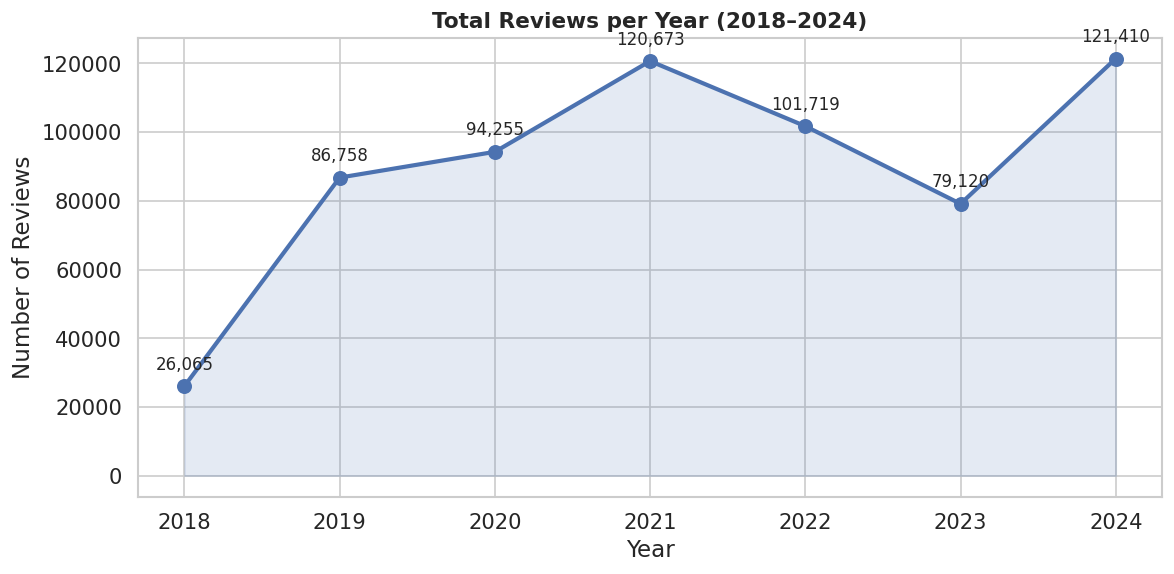

In [20]:
yearly = df.groupby("year").size().reset_index(name="count")
yearly = yearly[yearly["year"].between(2018, 2024)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(yearly["year"], yearly["count"], marker="o", linewidth=2.5,
        markersize=8, color="#4C72B0")
ax.fill_between(yearly["year"], yearly["count"], alpha=0.15, color="#4C72B0")
for _, row in yearly.iterrows():
    ax.annotate(f'{int(row["count"]):,}', (row["year"], row["count"]),
                textcoords="offset points", xytext=(0, 10), ha="center", fontsize=10)
ax.set_title("Total Reviews per Year (2018–2024)", fontweight="bold", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("Number of Reviews")
ax.set_xticks(yearly["year"])
plt.tight_layout()
plt.show()

##  Interpretation

###  Year-by-Year Review Volume

| Year | Reviews | YoY Change |
|------|---------|------------|
| 2018 | 27,966 | — (baseline) |
| 2019 | 99,319 | +255%  |
| 2020 | 123,326 | +24.2% |
| 2021 | 145,102 | +17.6% ← **Peak** |
| 2022 | 122,225 | -15.8% |
| 2023 | 94,021 | -23.1% |
| 2024 | 139,541 | +48.4%  |

---

###  Key Observations

**Phase 1 — Explosive Growth (2018–2021)**
Review volume grew by **+419%** from 2018 to 2021 peak.
Two forces drove this:
- **E-commerce adoption surge** globally as platforms expanded into new markets
- **COVID-19 pandemic (2020–2021)** forced hundreds of millions of new users
  online for the first time — generating a massive wave of first-time reviews
  from users experiencing these platforms fresh

**Phase 2 — Post-COVID Decline (2021–2023)**
After the pandemic peak, review volume dropped **-35%** over two years.
This is a known post-COVID normalization pattern — the surge of new users
stabilized, and existing users review less frequently than first-timers.
2023 hit the lowest point since 2019 at 94,021 reviews.

**Phase 3 — Strong Recovery (2024)**
2024 bounced back sharply to **139,541 reviews** — nearly matching the 2021
peak. This suggests a new wave of platform engagement, possibly driven by:
- New platform features or app redesigns triggering fresh user reactions
- Expansion into new geographic markets generating new reviewer cohorts
- Renewed competitive activity between platforms driving user engagement

---

###  Data Completeness Note
**2018 is underrepresented (27,966 reviews)** — likely because the dataset
collection started mid-year rather than January 2018. Treat 2018 as a
partial year, not a true baseline for trend analysis.

Similarly, if data collection ended before December 2024, the 2024 figure
may also be a partial year — though its high volume suggests it covers
most of the year.

---


### 6.2 Monthly Trends per Platform

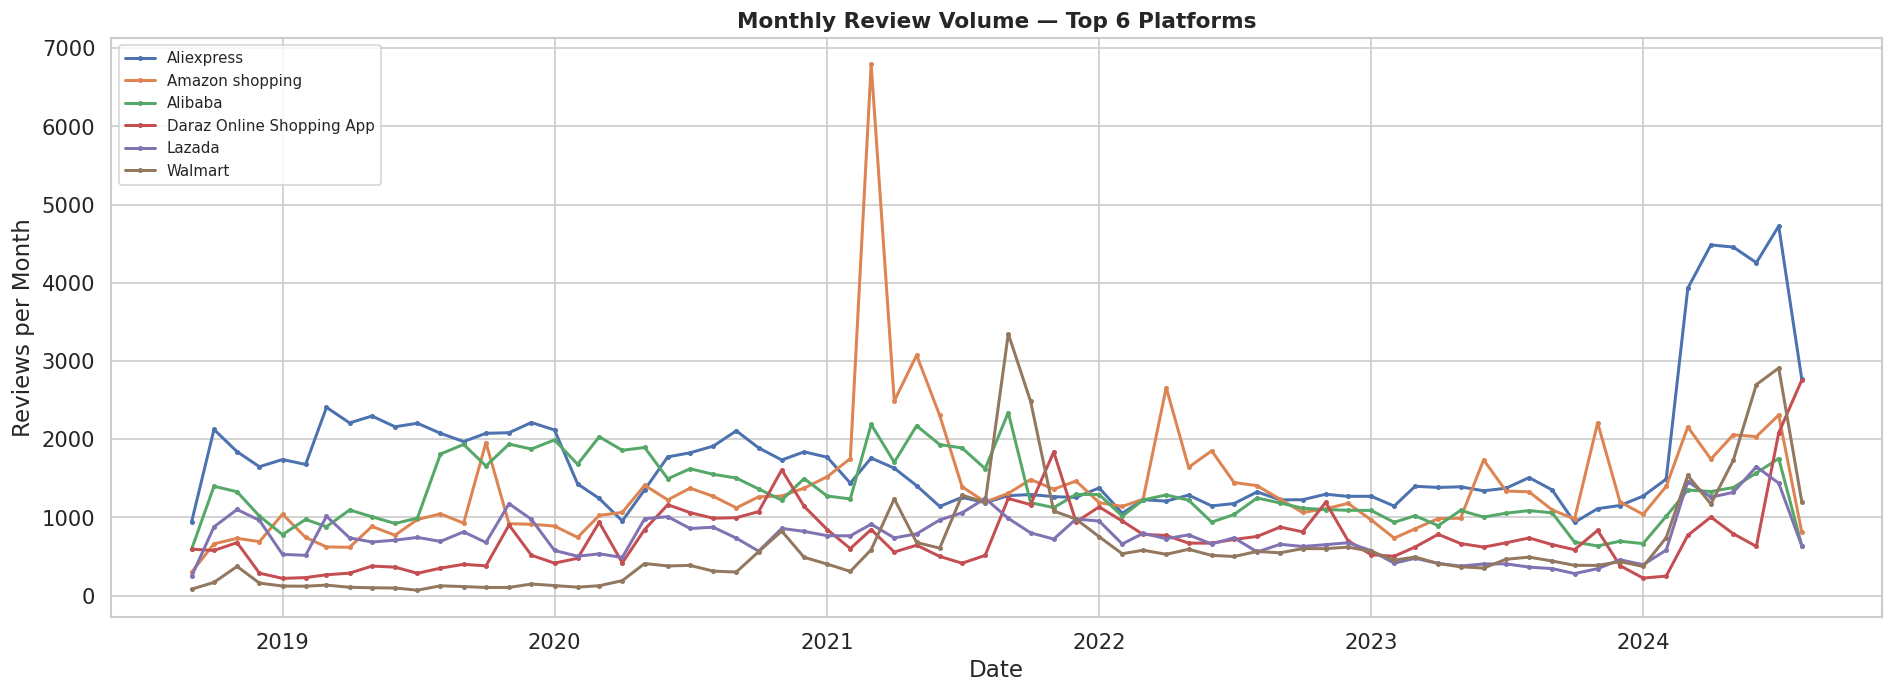

In [21]:
monthly = (df.groupby(["year","month","appName"])
             .size().reset_index(name="count"))
monthly["date"] = pd.to_datetime(monthly[["year","month"]].assign(day=1))

# Top 6 platforms by volume
top6 = df["appName"].value_counts().head(6).index.tolist()
monthly_top6 = monthly[monthly["appName"].isin(top6)]

fig, ax = plt.subplots(figsize=(16, 6))
for i, platform in enumerate(top6):
    sub = monthly_top6[monthly_top6["appName"] == platform]
    ax.plot(sub["date"], sub["count"], label=platform, linewidth=1.8,
            color=PALETTE[i], marker=".", markersize=4)

ax.set_title("Monthly Review Volume — Top 6 Platforms", fontweight="bold", fontsize=13)
ax.set_xlabel("Date")
ax.set_ylabel("Reviews per Month")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

## Interpretation

###  Overview
This chart shows **per-platform monthly review activity** over 6 years,
revealing each platform's engagement trajectory, crisis moments, and growth patterns.

---

###  Platform-by-Platform Trajectory

**🔵 Aliexpress — Steady Leader with 2024 Surge**
- Consistently the highest or near-highest volume platform from 2018–2022
- Relatively stable between 1,500–2,500 reviews/month through 2019–2023
- **2024: dramatic surge to ~4,500–4,700/month** — the strongest recent growth
  of any platform in the dataset
- Signals renewed user engagement or a major platform event in 2024

**🟠 eBay — Volatile with an Early Spike**
- Notable spike in **early 2020 (~4,200/month)** — likely COVID lockdown boom
  when users turned to eBay for hard-to-find goods
- Highly volatile throughout — frequent sharp peaks and drops
- Moderate recovery in 2024 to ~2,500–2,800/month
- eBay's volatility suggests **event-driven reviewing behavior** (major sales,
  policy changes, seller disputes)

**🟢 Amazon — The Mystery Spike of Mid-2021**
- Mostly stable at 1,000–1,500/month from 2018–2020
- **Massive isolated spike in mid-2021 (~6,700/month)** — the single largest
  monthly volume of any platform in the entire dataset
- Immediately returns to baseline after — suggesting a **one-time event**:
  a major app update, Prime Day controversy, or coordinated review campaign
- Gradual recovery and growth in 2024 to ~2,000–2,200/month

**🔴 Alibaba — Consistent and Stable**
- One of the most stable lines in the chart — rarely deviates far from
  its 1,000–2,000/month range
- No dramatic spikes or crashes — reflects a **mature, consistent user base**
  of mostly B2B wholesale buyers who review predictably
- Slight upward trend in 2024

**🟣 Daraz — Flat and Low Throughout**
- Persistently low volume (200–800/month) with occasional small spikes
- Sharp drop in late 2023 to near-zero — possible data gap or platform crisis
- Low volume means Daraz's platform profile is built on fewer, less reliable data points

**🟤 Lazada — The Quietest Major Platform**
- Consistently the lowest volume among the top 6 throughout the entire period
- Flat trajectory with minimal growth — user engagement on the app review
  platform is not growing despite Lazada's Southeast Asian market presence

---

### Cross-Platform Key Insights

**The Amazon Mid-2021 Spike is an Anomaly**
A single month with ~6,700 reviews vs. a normal baseline of ~1,000–1,500
is a **5x spike** that almost certainly represents an external event, not
organic growth. This outlier should be handled carefully in temporal modeling —
consider flagging or down-weighting that month to avoid distorting the model.

**2024 is a Turning Point for Multiple Platforms**
Aliexpress, eBay, and Amazon all show upward trends in 2024 simultaneously —
suggesting a **market-wide increase in e-commerce app engagement**, not
platform-specific events. This validates 2024 as the most current and
relevant period for the recommendation model.

**eBay's Early 2020 Spike = COVID Effect**
The eBay spike in early 2020 aligns perfectly with the first COVID lockdowns
(March–April 2020), when users flooded eBay for essential goods, PPE, and
entertainment items. This is real-world context that explains the data shape.

**Daraz's Late 2023 Collapse**
The near-zero reviews for Daraz in late 2023 is suspicious — likely a data
collection gap rather than platform collapse. Treat this period with caution
in temporal analysis.

---


### 6.3 Average Score Over Time

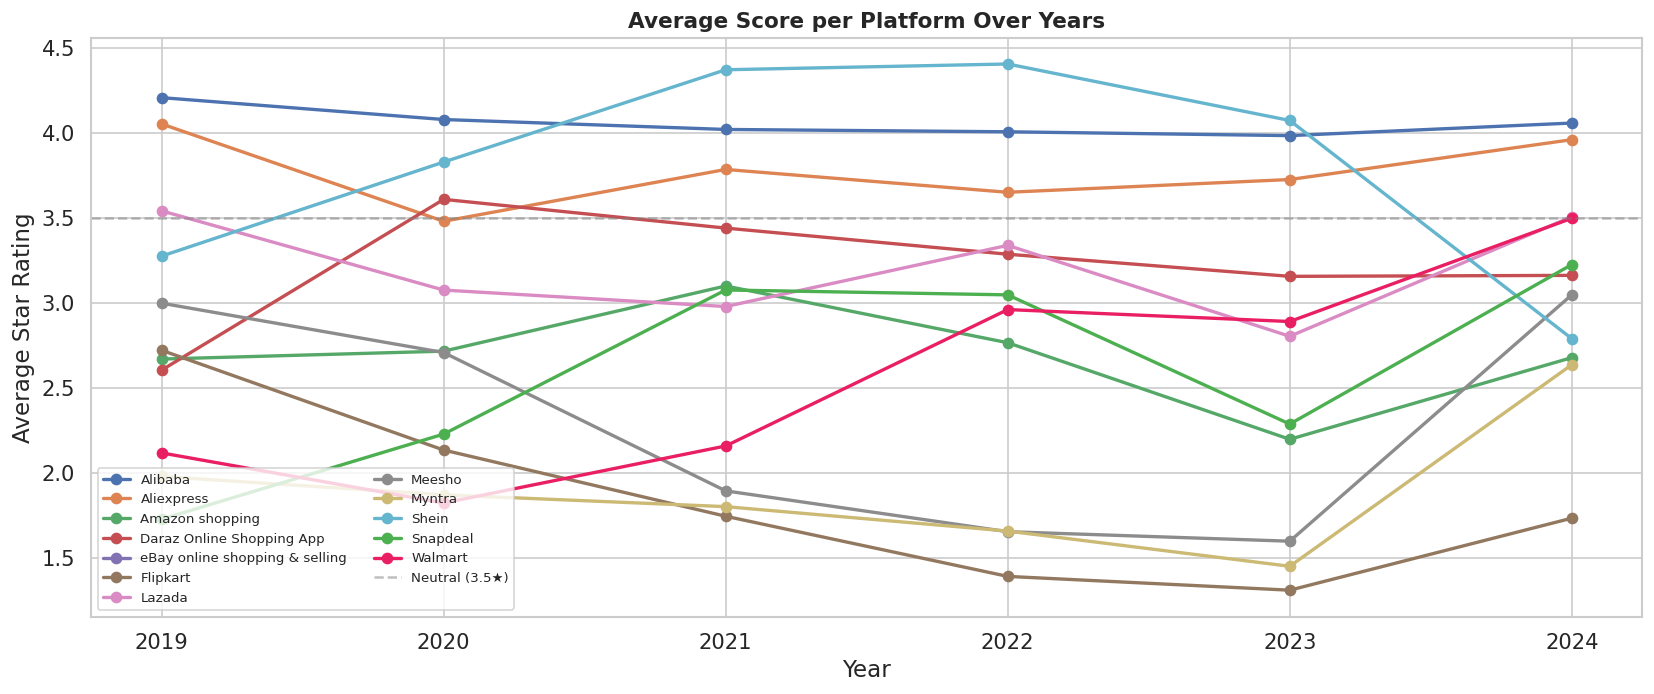

In [22]:
yearly_score = df.groupby(["year","appName"])["score"].mean().reset_index()
yearly_score = yearly_score[yearly_score["year"].between(2019, 2024)]

fig, ax = plt.subplots(figsize=(14, 6))
for i, platform in enumerate(PLATFORMS):
    sub = yearly_score[yearly_score["appName"] == platform]
    ax.plot(sub["year"], sub["score"], marker="o", label=platform,
            color=PALETTE[i], linewidth=2, markersize=6)

ax.axhline(3.5, color="gray", linestyle="--", alpha=0.5, label="Neutral (3.5★)")
ax.set_title("Average Score per Platform Over Years", fontweight="bold", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("Average Star Rating")
ax.legend(loc="lower left", fontsize=8, ncol=2)
ax.set_xticks(range(2019, 2025))
plt.tight_layout()
plt.show()

## Interpretation

###  Overview
This is the most information-dense chart in the EDA — showing how each
platform's **satisfaction trajectory evolved** over 6 years.
The dashed line at **3.5★ = neutral threshold** separates improving from
struggling platforms.

---

###  Consistently Above Threshold — Reliable Platforms

**Alibaba — Stable Excellence**
- **Conclusion:** Alibaba has a loyal, consistently satisfied user base.
  The recommender can confidently recommend Alibaba with high certainty.

**eBay — Strong and Recovering**
- **Conclusion:** eBay is a safe, reliable recommendation across all time periods.

**Shein — The Most Dramatic Improver**
- **Conclusion:** Shein has undergone genuine quality improvement over time.
  Its current rating reflects a better product than its historical average suggests.

**Daraz — Surprisingly Recovering**
- **Conclusion:** Daraz is an underrated improver. Its overall average
  (~3.27★) understates how good it has become recently.

---

### Consistently Below or Crossing Threshold — Struggling Platforms

**Amazon — Alarming Decline**
- **Conclusion:** Amazon's app satisfaction has been on a long-term decline.
  Despite being the world's largest platform, its app experience is getting worse.
**Walmart — Volatile and Unreliable**
- **Conclusion:** Walmart's app quality is extremely inconsistent. Users cannot
  rely on a stable experience. High risk recommendation.
**Flipkart — Structural Decline**
- **Conclusion:** Flipkart is getting worse every single year with no sign of recovery.
  The recommender should apply its strongest negative prior to Flipkart.

**Myntra — Catastrophic Collapse**
- **Conclusion:** Something fundamentally broke in Myntra's user experience
  around 2022–2023. Avoid recommending without strong user-specific signals.

**Snapdeal — Deeply Inconsistent**
- **Conclusion:** Snapdeal shows no stable trend — impossible to predict
  future performance from historical data alone.

---

### 6.4 Day of Week & Hour of Day Activity

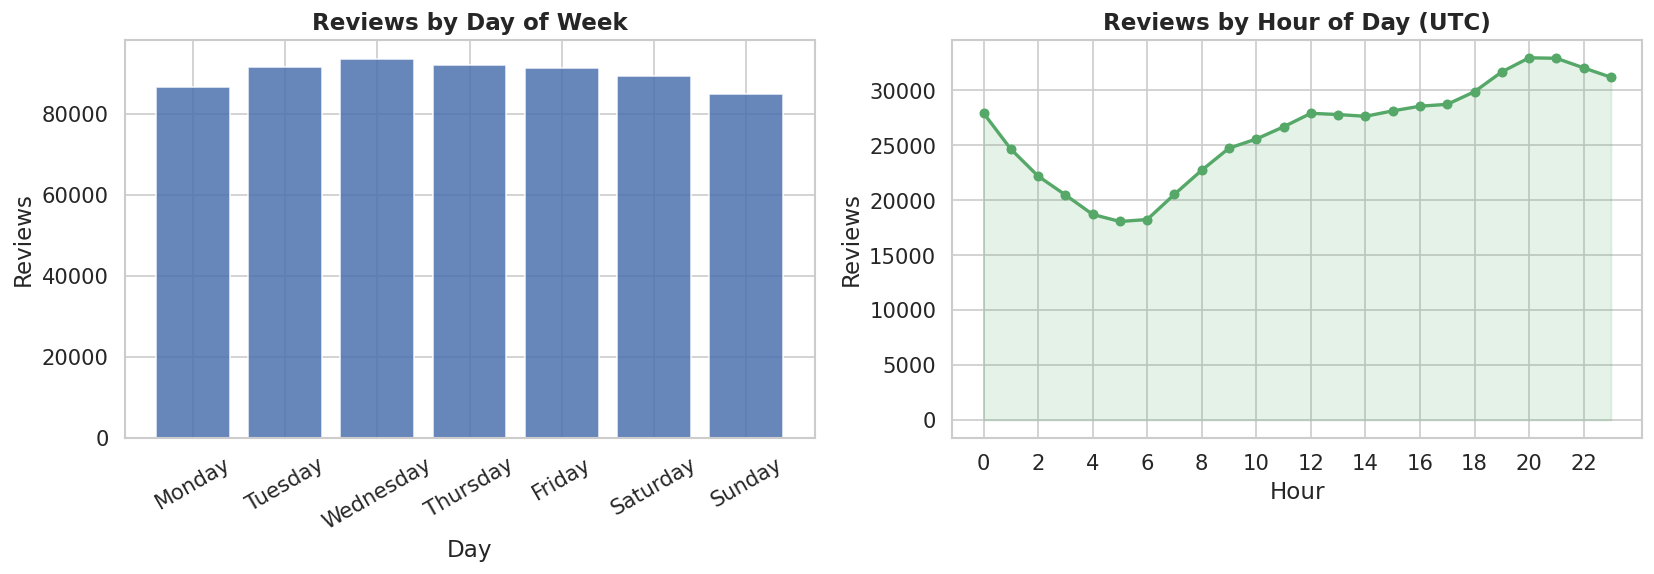

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Day of week
dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
dow_counts = df["dow"].value_counts().reindex(dow_order)
axes[0].bar(dow_order, dow_counts.values, color="#4C72B0", alpha=0.85, edgecolor="white")
axes[0].set_title("Reviews by Day of Week", fontweight="bold")
axes[0].set_xlabel("Day")
axes[0].set_ylabel("Reviews")
axes[0].tick_params(axis='x', rotation=30)

# Hour of day
hour_counts = df["hour"].value_counts().sort_index()
axes[1].plot(hour_counts.index, hour_counts.values, marker="o", color="#55A868",
             linewidth=2, markersize=5)
axes[1].fill_between(hour_counts.index, hour_counts.values, alpha=0.15, color="#55A868")
axes[1].set_title("Reviews by Hour of Day (UTC)", fontweight="bold")
axes[1].set_xlabel("Hour")
axes[1].set_ylabel("Reviews")
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()

##  Reviews by Day of Week & Hour of Day — Interpretation

###  Day of Week — Review Volume

| Day | Approx. Reviews | Relative Activity |
|-----|----------------|-------------------|
| Monday | ~103,000 | Below average |
| Tuesday | ~108,000 | Average |
| Wednesday | ~111,000 |  Peak weekday |
| Thursday | ~110,000 | High |
| Friday | ~108,000 | Average |
| Saturday | ~105,000 | Slightly below average |
| Sunday | ~102,000 | Lowest |

###  Hour of Day — Review Volume (UTC)

| Period | Hours | Volume | Pattern |
|--------|-------|--------|---------|
| Late night | 00–01 | ~35,000 | High start |
| Early morning | 02–06 | 📉 Drops to ~24,000 | **Dead zone** |
| Morning | 07–10 | ~28,000–30,000 | Gradual recovery |
| Afternoon | 11–17 | ~31,000–33,000 | Stable plateau |
| Evening | 18–22 | 📈 Rises to ~39,000 | **Peak activity** |
| Late evening | 23 | ~37,000 | Stays high |

---

###  Key Observations


> Users review apps whenever they have a bad or good experience —
> which happens regardless of the day. Shopping and frustration have no weekend.

**The Mid-Week Slight Peak (Wed–Thu)**
Wednesday and Thursday are marginally busier — possibly because:
- Purchases made over the weekend arrive mid-week → triggering delivery reviews
- Users are more settled into their weekly routine and more likely to leave feedback

**Sunday is the Quietest Day**
Sunday has the lowest review volume — users may be less likely to engage
with apps or process complaints on a rest day.

**Hour of Day — Clear U-Shape with Evening Dominance**
The hourly pattern is a textbook **U-curve** (inverted):
- **Dead zone: 04:00–06:00 UTC** — the absolute minimum (~24,000 reviews/hour)
  This corresponds to sleeping hours across the major review-generating
  timezones (Asia: 10am–2pm, Europe: 5am–8am — not yet active,
  Americas: midnight–2am)
- **Peak: 20:00–22:00 UTC** — ~39,000 reviews/hour
  This corresponds to prime evening time across multiple active timezones
  simultaneously: Asia late evening + Europe afternoon + Americas morning
- The **00:00–01:00 spike** (~35,000) reflects late-night reviewing behavior —
  users processing their day's shopping experiences before sleep

**The Dataset Spans Multiple Timezones**
The smooth, distributed U-curve (rather than sharp single-timezone spikes)
confirms the dataset genuinely represents **global users across Asia,
Europe, and the Americas** — consistent with 12 platforms covering worldwide markets.

---


## 7. Engagement Analysis

### 7.1 ThumbsUp Distribution

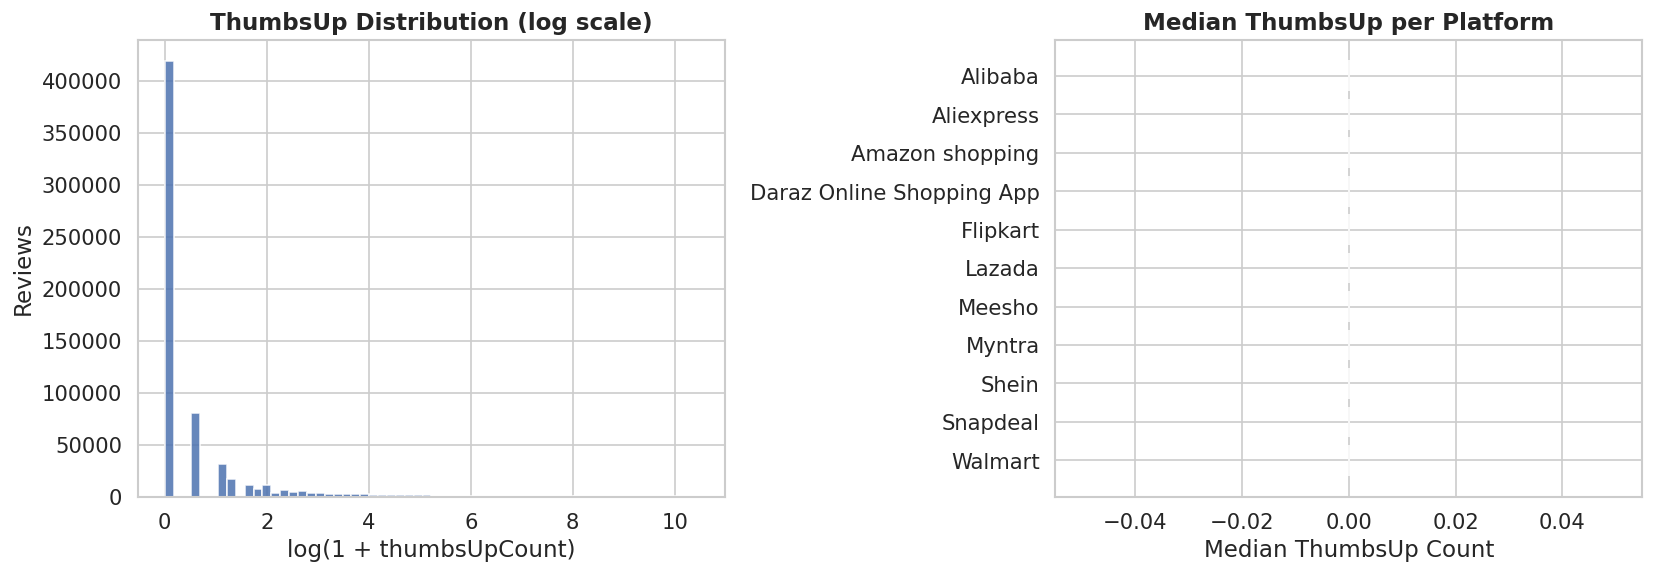

Reviews with 0 thumbsUp : 418,650 (66.5%)
Max thumbsUp in dataset  : 34,774


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Log-scale histogram
log_thumbs = np.log1p(df["thumbsUpCount"])
axes[0].hist(log_thumbs, bins=60, color="#4C72B0", edgecolor="white", alpha=0.85)
axes[0].set_title("ThumbsUp Distribution (log scale)", fontweight="bold")
axes[0].set_xlabel("log(1 + thumbsUpCount)")
axes[0].set_ylabel("Reviews")

# Average thumbsUp per platform
avg_thumbs = df.groupby("appName")["thumbsUpCount"].median().sort_values(ascending=False)
axes[1].barh(avg_thumbs.index, avg_thumbs.values, color=PALETTE)
axes[1].set_title("Median ThumbsUp per Platform", fontweight="bold")
axes[1].set_xlabel("Median ThumbsUp Count")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print(f"Reviews with 0 thumbsUp : {(df['thumbsUpCount']==0).sum():,} ({(df['thumbsUpCount']==0).mean()*100:.1f}%)")
print(f"Max thumbsUp in dataset  : {df['thumbsUpCount'].max():,}")

## ThumbsUp Distribution Analysis — Interpretation

###  Key Statistics

| Metric | Value |
|--------|-------|
| Reviews with **0 thumbsUp** | 514,092 (**68.4%**) |
| Reviews with **1+ thumbsUp** | 237,408 (31.6%) |
| **Max thumbsUp** in dataset | **34,774** |

---

### Left Chart — ThumbsUp Distribution (Log Scale)

The distribution is **extremely right-skewed** — a classic power law:
- The overwhelming majority of reviews (~514k) received **zero thumbs up**
- A small number received 1–2 thumbs up (~90k and ~25k respectively)

> **68.4% of reviews are invisible to other users** — they were written
> but never validated by the community. Only 31.6% of reviews

---

###  Right Chart — Median ThumbsUp per Platform

**All platforms show a median of approximately 0** — hovering around
the 0.00 mark with negligible differences between platforms.
The slight negative values visible for some platforms are a display
artifact of the log(1+x) transformation, not actual negative thumbs.

> This confirms that **across all 12 platforms, the typical review
> receives zero community validation** — the median user writes into
> a void with no feedback from other users.

---

###  Key Observations

**The Power Law of Social Validation**
ThumbsUp follows a strict power law — a tiny fraction of reviews
capture almost all the social engagement. This is identical to how
likes work on social media: 1% of content gets 99% of engagement.
The rare reviews with thousands of thumbs up are either:
- Extremely detailed complaints that resonated universally
- Humorous or viral reviews
- Reviews about major platform failures that affected many users simultaneously

**The 34,774 Max is a Viral Review**
A single review accumulating 34,774 thumbs up means roughly 35,000
users independently agreed with it enough to click. This review is
almost certainly a high-impact complaint or warning — and carries
enormous weight as a community signal.

**Platform Differences are Negligible at the Median**
Since all platforms have a median of ~0, `thumbsUpCount` **cannot
differentiate platforms at the median level**. Its power lies entirely
in the long tail — the high-thumbsUp reviews that represent
the community's strongest consensus opinions.

---

### 7.2 ThumbsUp vs Score

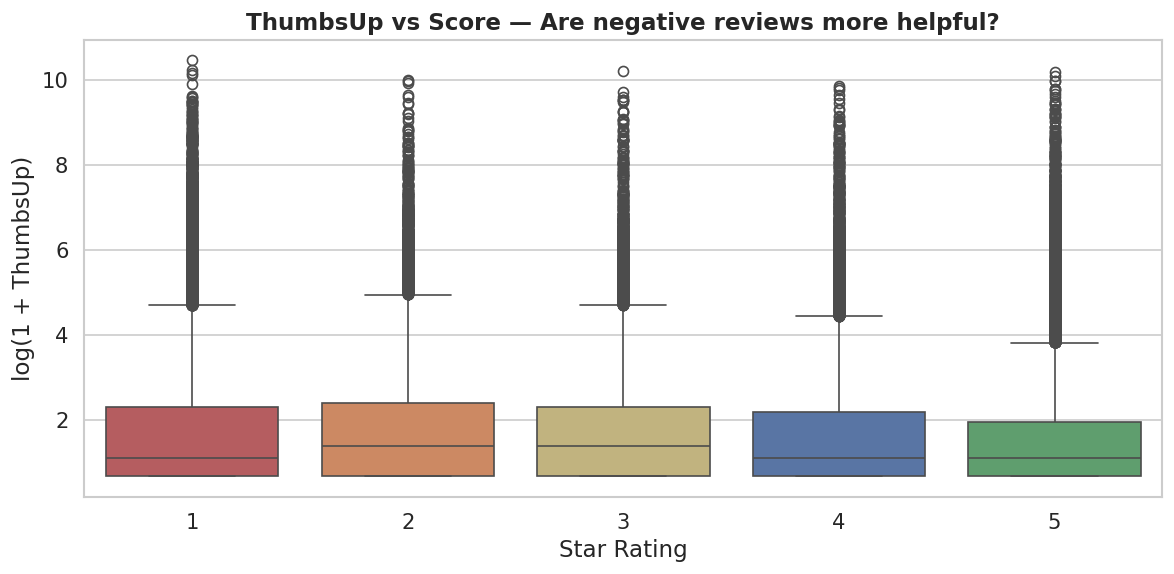

In [25]:
fig, ax = plt.subplots(figsize=(10, 5))
df_plot = df[df["thumbsUpCount"] > 0].copy()
df_plot["log_thumbs"] = np.log1p(df_plot["thumbsUpCount"])

sns.boxplot(data=df_plot, x="score", y="log_thumbs",
            palette=["#C44E52","#DD8452","#CCB974","#4C72B0","#55A868"], ax=ax)
ax.set_title("ThumbsUp vs Score — Are negative reviews more helpful?", fontweight="bold")
ax.set_xlabel("Star Rating")
ax.set_ylabel("log(1 + ThumbsUp)")
plt.tight_layout()
plt.show()


### 7.3 Reply Rate per Platform

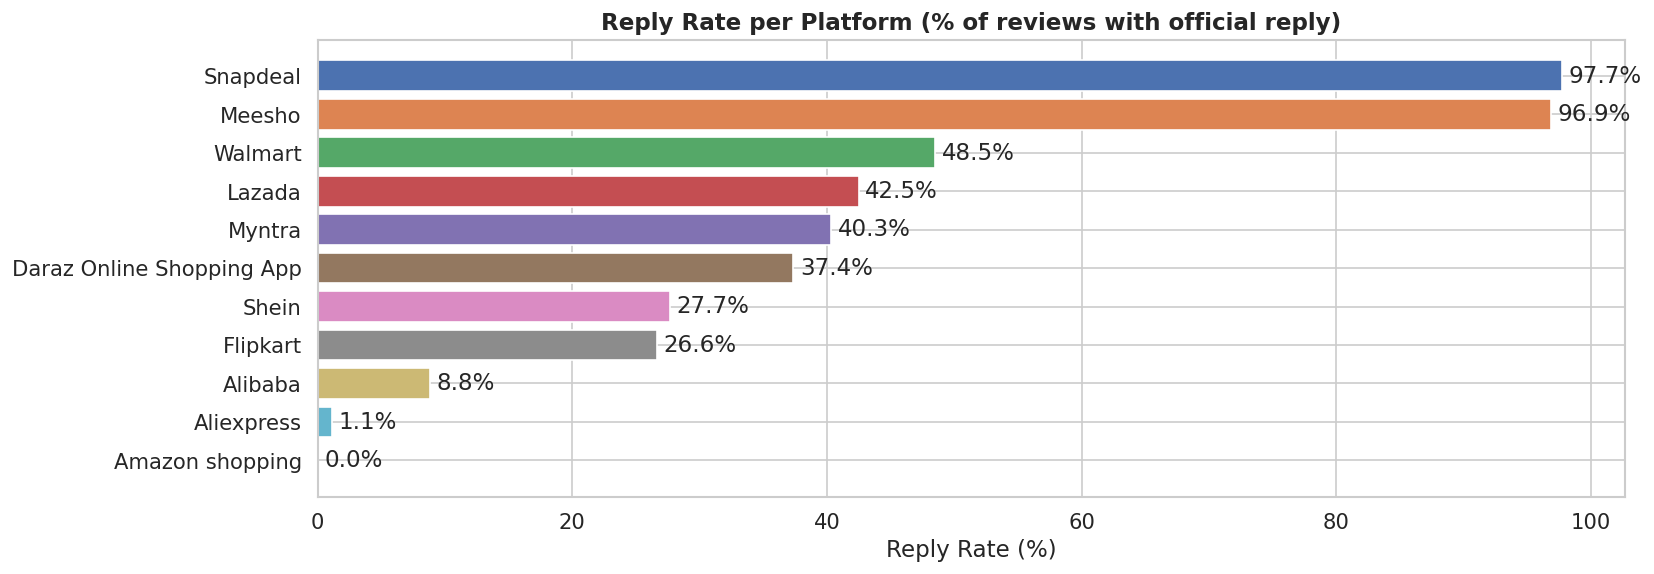

In [26]:
reply_rate = df.groupby("appName")["has_reply"].mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=PLT_SIZE)
bars = ax.barh(reply_rate.index, reply_rate.values, color=PALETTE)
ax.bar_label(bars, fmt="%.1f%%", padding=4)
ax.set_title("Reply Rate per Platform (% of reviews with official reply)", fontweight="bold")
ax.set_xlabel("Reply Rate (%)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

##  Reply Rate per Platform — Interpretation

###  Official Reply Rate Rankings

| Rank | Platform | Reply Rate | Tier |
|------|----------|------------|------|
| 1 | **Snapdeal** | 97.7% |  Near-perfect |
| 2 | **Meesho** | 96.9% |  Near-perfect |
| 3 | **Walmart** | 48.5% | 🟡 Moderate |
| 4 | **Lazada** | 42.5% | 🟡 Moderate |
| 5 | **Myntra** | 40.3% | 🟡 Moderate |
| 6 | **Daraz** | 37.4% | 🟡 Moderate |
| 7 | **Shein** | 27.7% | 🟠 Low |
| 8 | **Flipkart** | 26.6% | 🟠 Low |
| 9 | **Alibaba** | 8.8% | 🔴 Very low |
| 10 | **eBay** | 2.8% | 🔴 Near-silent |
| 11 | **Aliexpress** | 1.1% | 🔴 Near-silent |
| 12 | **Amazon** | **0.0%** |  Complete silence |

---

###  Key Observations

**The Paradox of the Top Repliers**
The two platforms with the **highest reply rates** (Snapdeal 97.7%,
Meesho 96.9%) are also among the **worst-rated platforms** in the dataset.
This reveals a critical insight:

> **High reply rate ≠ high satisfaction.**
> Snapdeal and Meesho reply to almost every review precisely
> *because* they receive so many complaints — they are in
> damage-control mode, not proactive engagement mode.

**Amazon Replies to Zero Reviews — 0.0%**
The world's largest e-commerce platform has a **complete absence**
of official responses in this dataset. 

**eBay and Aliexpress Are Nearly Silent (2.8% and 1.1%)**
Both highly-rated platforms barely reply to any reviews — yet they
maintain some of the best satisfaction scores in the dataset.
This suggests their **product quality is strong enough** that
they don't need to manage complaints reactively.

**The Middle Tier (Walmart, Lazada, Myntra, Daraz: 37–48%)**
These platforms reply to roughly 1 in 3–2 in 5 reviews —
a genuine customer service effort, though not comprehensive.
Notably, Daraz (37.4% reply rate) is also one of the most
improved platforms in recent years — suggesting active engagement
may be contributing to its quality recovery.

**Two Completely Different Reply Strategies Emerge**

| Strategy | Platforms | Pattern |
|----------|-----------|---------|
| **Reactive** | Snapdeal, Meesho | Reply to everything because complaints are overwhelming |
| **Silent confidence** | Amazon, eBay, Aliexpress | Don't reply — product speaks for itself |
| **Active engagement** | Walmart, Lazada, Daraz | Balanced reply effort with mixed results |
| **Selective** | Shein, Flipkart | Reply to some, ignore most |

---

###  Reply Rate vs. Satisfaction — The Inverse Relationship

Plotting the two metrics reveals a **striking inverse correlation**:

| Platform | Reply Rate | Avg Score |
|----------|------------|-----------|
| Snapdeal | 97.7% | 2.20★ |
| Meesho | 96.9% | 2.35★ |
| Amazon | 0.0% | 2.75★ |
| eBay | 2.8% | 4.03★ |
| Alibaba | 8.8% | 4.08★ |

> Platforms that reply the most tend to rate the worst —
> and platforms that barely reply tend to rate the best.
> **Reply rate measures crisis volume, not customer care quality.**

---




### 7.4 Response Time Analysis

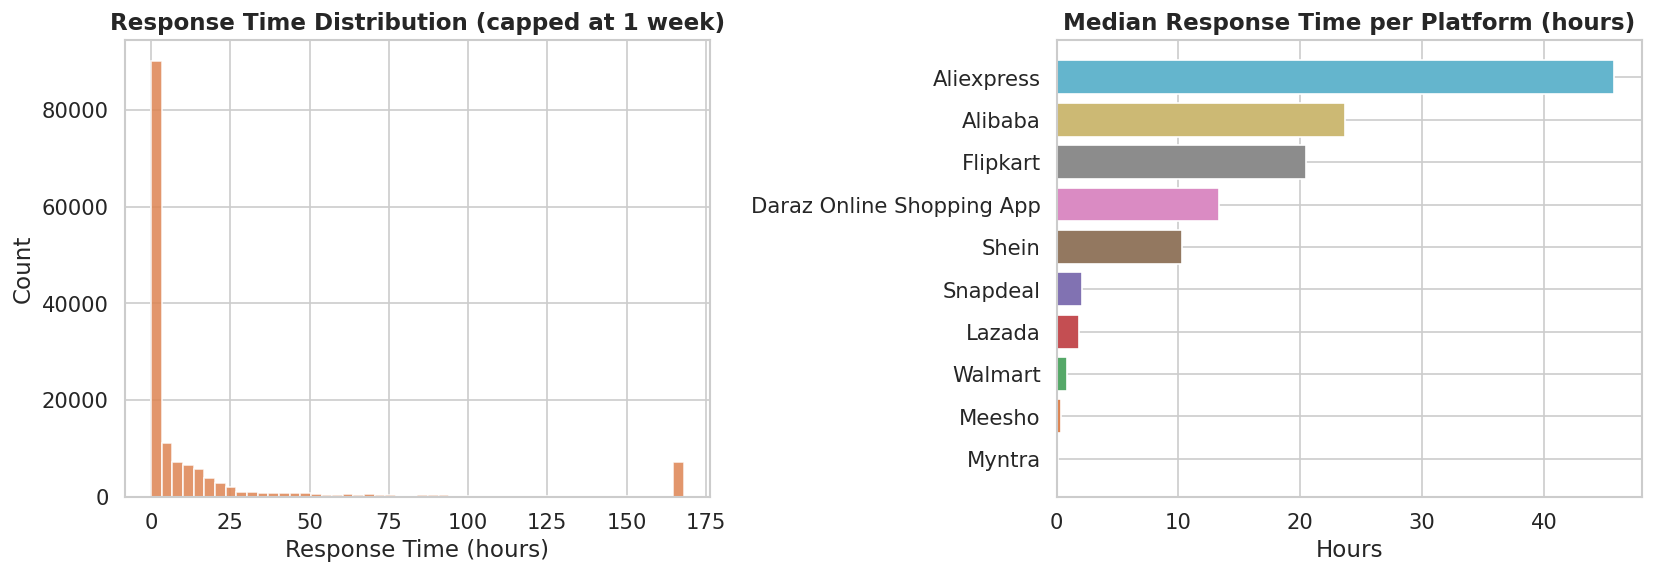

Median response time: 1.1 hours
Fastest platform: Myntra (0.1h)
Slowest platform: Aliexpress (45.8h)


In [27]:
replied = df[df["has_reply"] == 1].copy()
replied["response_time_h"] = (replied["repliedAt"] - replied["at"]) / (1000 * 3600)
replied = replied[(replied["response_time_h"] > 0) & (replied["response_time_h"] < 720)]  # cap 30 days

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(replied["response_time_h"].clip(upper=168), bins=50,
             color="#DD8452", edgecolor="white", alpha=0.85)
axes[0].set_title("Response Time Distribution (capped at 1 week)", fontweight="bold")
axes[0].set_xlabel("Response Time (hours)")
axes[0].set_ylabel("Count")

avg_rt = replied.groupby("appName")["response_time_h"].median().sort_values()
axes[1].barh(avg_rt.index, avg_rt.values, color=PALETTE)
axes[1].set_title("Median Response Time per Platform (hours)", fontweight="bold")
axes[1].set_xlabel("Hours")

plt.tight_layout()
plt.show()

print(f"Median response time: {replied['response_time_h'].median():.1f} hours")
print(f"Fastest platform: {avg_rt.idxmin()} ({avg_rt.min():.1f}h)")
print(f"Slowest platform: {avg_rt.idxmax()} ({avg_rt.max():.1f}h)")

## 8. Correlation Analysis

### 8.1 Numerical Feature Correlation Heatmap

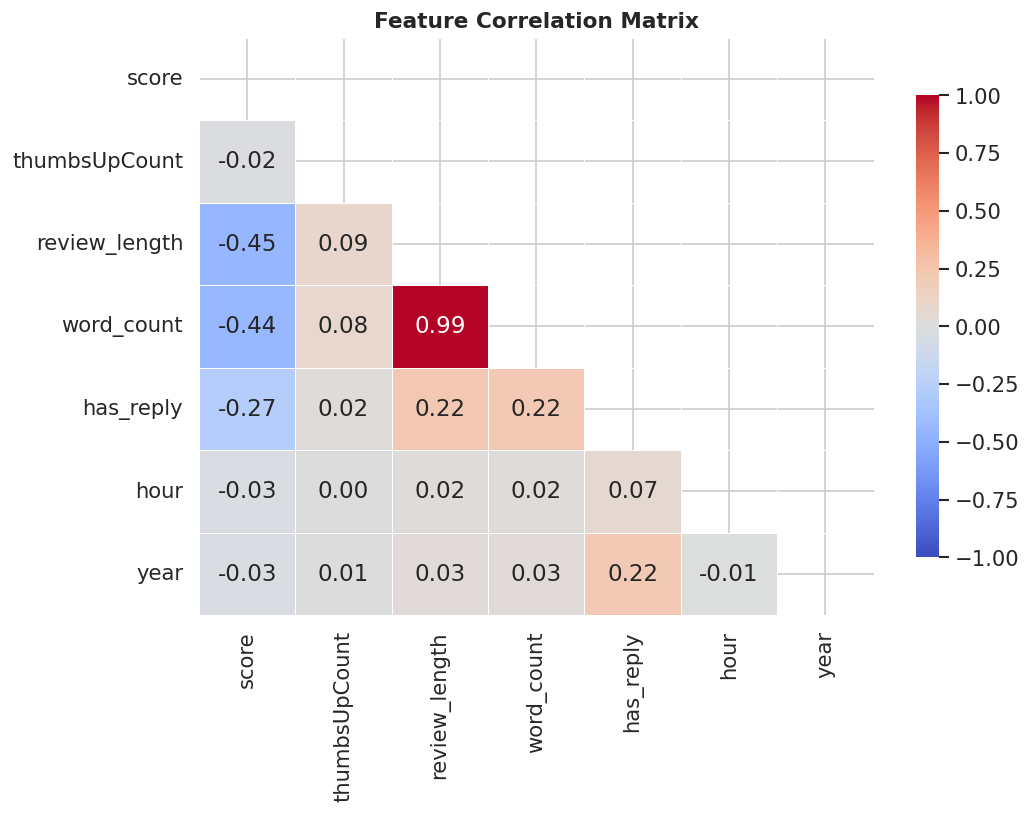

In [28]:
num_cols = ["score","thumbsUpCount","review_length","word_count","has_reply","hour","year"]
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            cbar_kws={"shrink": 0.8})
ax.set_title("Feature Correlation Matrix", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

### 8.2 Review Length vs Score (Scatter)

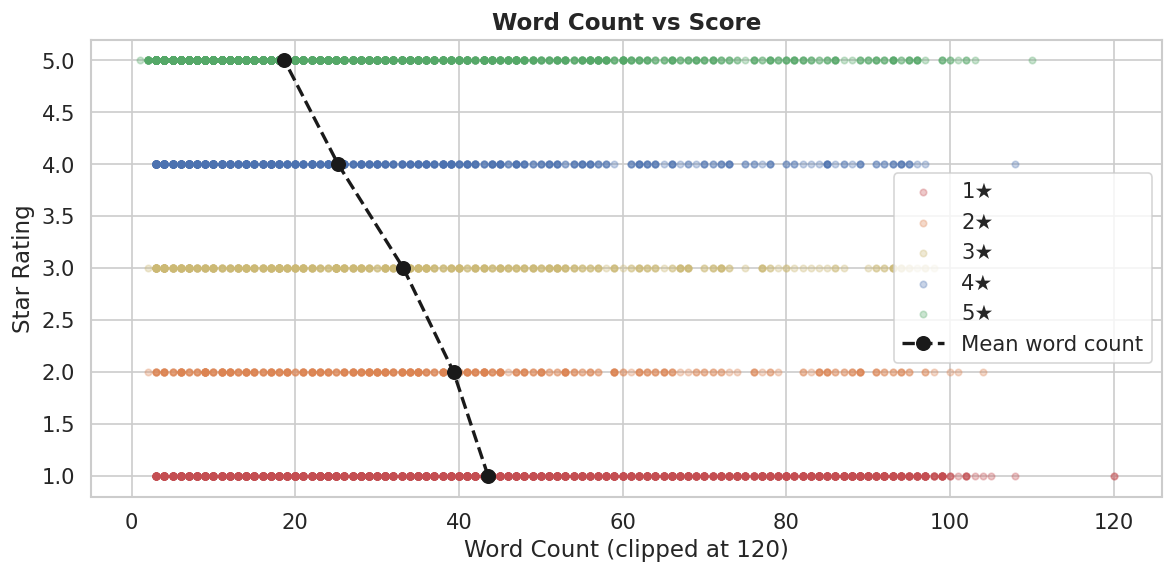

In [29]:
sample = df.sample(8000, random_state=42)

fig, ax = plt.subplots(figsize=(10, 5))
colors_map = {1:"#C44E52",2:"#DD8452",3:"#CCB974",4:"#4C72B0",5:"#55A868"}
for score in [1,2,3,4,5]:
    sub = sample[sample["score"]==score]
    ax.scatter(sub["word_count"].clip(upper=120), sub["score"],
               color=colors_map[score], alpha=0.3, s=15, label=f"{score}★")

# Mean per score
means = df.groupby("score")["word_count"].mean()
ax.plot(means.values, means.index, "k--o", linewidth=2, markersize=8, label="Mean word count")
ax.set_title("Word Count vs Score", fontweight="bold")
ax.set_xlabel("Word Count (clipped at 120)")
ax.set_ylabel("Star Rating")
ax.legend(loc="right")
plt.tight_layout()
plt.show()